# 07. Probability Calibration

## 1. Notebook Objective and Calibration Framework

The walk-forward backtest produced genuinely out-of-sample probability forecasts for five models across five complete Premier League seasons.

Each model generated forecasts for 1,900 unseen fixtures, producing 9,500 fixture-model probability distributions in total.

The walk-forward analysis identified Independent Poisson as the leading model by mean log loss:

$$
\overline{\operatorname{LogLoss}}_{\text{Poisson}}
=
0.985002.
$$

However, strong log loss does not guarantee that a model is well calibrated.

A calibrated model should satisfy the approximate relationship:

$$
P(Y=k\mid \hat{p}_k=p)
\approx
p.
$$

For example, among fixtures where a model assigns a 60% probability to a home win, the home team should win approximately 60% of the time.

A model may instead be:

- **overconfident**, when predicted probabilities are more extreme than observed frequencies;
- **underconfident**, when predicted probabilities remain too close to the centre;
- well calibrated for home wins but poorly calibrated for draws or away wins;
- well ranked by log loss while still displaying systematic probability bias.

### Research Questions

This notebook will investigate:

1. Are the original walk-forward probabilities well calibrated?
2. Which outcomes and probability ranges show the largest calibration errors?
3. Are the models systematically overconfident or underconfident?
4. Can calibration improve log loss and Brier score on later unseen seasons?
5. Which original or calibrated model should be selected as the final probability engine?

### Models Considered

The primary calibration analysis will focus on the three strongest walk-forward models:

1. Independent Poisson;
2. Direct Probability Ensemble;
3. Tuned Random Forest.

The remaining models will be retained as reference points where useful.

### Calibration Diagnostics

The original forecasts will be evaluated using:

- reliability diagrams;
- outcome-specific calibration tables;
- Expected Calibration Error;
- Maximum Calibration Error;
- Brier score;
- log loss;
- predicted-confidence distributions.

For outcome $k$, predictions will be divided into probability bins.

Within bin $b$:

$$
\operatorname{Confidence}(b)
=
\frac{1}{|b|}
\sum_{i\in b}\hat{p}_{i,k},
$$

and

$$
\operatorname{Frequency}(b)
=
\frac{1}{|b|}
\sum_{i\in b}\mathbb{1}(y_i=k).
$$

A well-calibrated model should satisfy:

$$
\operatorname{Confidence}(b)
\approx
\operatorname{Frequency}(b).
$$

### Chronological Calibration Design

Calibration must not be fitted and evaluated using the same forecasts.

The notebook will therefore use an expanding-window structure:

| Calibration training seasons | Unseen calibrated evaluation season |
|---|---|
| 2020–21 | 2021–22 |
| 2020–21 to 2021–22 | 2022–23 |
| 2020–21 to 2022–23 | 2023–24 |
| 2020–21 to 2023–24 | 2024–25 |

This produces calibrated predictions for 1,520 unseen fixtures per model.

The first walk-forward season, 2020–21, supplies the initial calibration-training sample and is not included in the calibrated performance comparison.

### Candidate Calibration Methods

The notebook will compare:

- the original uncalibrated probabilities;
- sigmoid calibration;
- isotonic calibration.

Each calibration model will be fitted using earlier out-of-sample forecasts only.

The final model will be selected using later unseen-season log loss, supported by Brier score and calibration diagnostics.

## 2. Load and Validate the Walk-Forward Probability Forecasts

The calibration analysis uses the fixture-level probability forecasts exported from the walk-forward backtest.

Each row represents one model forecast for one unseen Premier League fixture and contains:

- fixture identifiers;
- evaluation season;
- model name;
- observed result;
- predicted result;
- home-win probability;
- draw probability;
- away-win probability.

The file should contain:

- 9,500 forecast rows;
- 1,900 unique fixtures;
- five models;
- five evaluation seasons;
- 380 fixtures per model in each season.

Every probability distribution must satisfy:

$$
P(H)+P(D)+P(A)=1.
$$

This section will also verify that all probabilities are finite, lie between zero and one, and remain aligned with the observed match outcomes.

In [1]:
# ============================================================
# 2. Load and Validate the Walk-Forward Probability Forecasts
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# Locate the project root
# ------------------------------------------------------------

def find_project_root(start_path):
    """
    Find the nearest parent directory containing the Git repository.
    """

    start_path = Path(start_path).resolve()

    for directory in [
        start_path,
        *start_path.parents,
    ]:
        if (directory / ".git").exists():
            return directory

    raise FileNotFoundError(
        "Could not locate the project root containing .git."
    )


project_root = find_project_root(
    Path.cwd()
)


# ------------------------------------------------------------
# Define the walk-forward probability file
# ------------------------------------------------------------

walk_forward_probability_path = (
    project_root
    / "outputs"
    / "walk_forward"
    / "walk_forward_fixture_probabilities.csv"
)


assert walk_forward_probability_path.exists(), (
    "The walk-forward probability export could not be found. "
    "Run the export section of Notebook 6 first."
)


# ------------------------------------------------------------
# Load the probability forecasts
# ------------------------------------------------------------

calibration_data = pd.read_csv(
    walk_forward_probability_path
)


# ------------------------------------------------------------
# Define expected columns
# ------------------------------------------------------------

identifier_candidates = {
    "Season": [
        "Season",
        "season",
    ],
    "Date": [
        "Date",
        "date",
        "MatchDate",
        "match_date",
    ],
    "HomeTeam": [
        "HomeTeam",
        "home_team",
        "Home",
    ],
    "AwayTeam": [
        "AwayTeam",
        "away_team",
        "Away",
    ],
}


def find_first_existing_column(
    dataframe,
    candidates,
    label,
):
    """
    Return the first candidate column present in a dataframe.
    """

    for candidate in candidates:

        if candidate in dataframe.columns:

            return candidate

    raise KeyError(
        f"Could not identify the {label} column. "
        f"Checked: {candidates}"
    )


season_column = find_first_existing_column(
    calibration_data,
    identifier_candidates["Season"],
    "season",
)

date_column = find_first_existing_column(
    calibration_data,
    identifier_candidates["Date"],
    "date",
)

home_team_column = find_first_existing_column(
    calibration_data,
    identifier_candidates["HomeTeam"],
    "home team",
)

away_team_column = find_first_existing_column(
    calibration_data,
    identifier_candidates["AwayTeam"],
    "away team",
)


fixture_key_columns = [
    season_column,
    date_column,
    home_team_column,
    away_team_column,
]


required_columns = (
    fixture_key_columns
    + [
        "EvaluationSeason",
        "Model",
        "ActualOutcome",
        "PredictedOutcome",
        "Probability_H",
        "Probability_D",
        "Probability_A",
    ]
)


missing_columns = [
    column
    for column in required_columns
    if column not in calibration_data.columns
]


assert not missing_columns, (
    "The calibration dataset is missing required columns: "
    f"{missing_columns}"
)


# ------------------------------------------------------------
# Standardise identifiers
# ------------------------------------------------------------

calibration_data = (
    calibration_data
    .copy()
)


calibration_data[
    date_column
] = pd.to_datetime(
    calibration_data[
        date_column
    ],
    errors="raise",
).dt.normalize()


for column in [
    home_team_column,
    away_team_column,
]:

    calibration_data[column] = (
        calibration_data[column]
        .astype(str)
        .str.strip()
    )


for column in [
    season_column,
    "EvaluationSeason",
    "Model",
    "ActualOutcome",
    "PredictedOutcome",
]:

    calibration_data[column] = (
        calibration_data[column]
        .astype(str)
        .str.strip()
    )


# ------------------------------------------------------------
# Define probability columns and class order
# ------------------------------------------------------------

CLASS_ORDER = [
    "H",
    "D",
    "A",
]


PROBABILITY_COLUMNS = [
    "Probability_H",
    "Probability_D",
    "Probability_A",
]


# ------------------------------------------------------------
# Validate row counts and dataset structure
# ------------------------------------------------------------

assert len(
    calibration_data
) == 9500, (
    "Expected 9,500 fixture-model forecasts, "
    f"but found {len(calibration_data):,}."
)


assert calibration_data[
    "Model"
].nunique() == 5, (
    "Expected probability forecasts from five models."
)


assert calibration_data[
    "EvaluationSeason"
].nunique() == 5, (
    "Expected probability forecasts from five seasons."
)


assert set(
    calibration_data[
        "ActualOutcome"
    ].unique()
) == set(
    CLASS_ORDER
), (
    "The observed outcome column contains unexpected values."
)


assert set(
    calibration_data[
        "PredictedOutcome"
    ].unique()
).issubset(
    set(
        CLASS_ORDER
    )
), (
    "The predicted outcome column contains unexpected values."
)


# ------------------------------------------------------------
# Validate probabilities
# ------------------------------------------------------------

assert calibration_data[
    PROBABILITY_COLUMNS
].notna().all().all(), (
    "At least one predicted probability is missing."
)


assert np.isfinite(
    calibration_data[
        PROBABILITY_COLUMNS
    ].to_numpy()
).all(), (
    "At least one predicted probability is non-finite."
)


assert (
    calibration_data[
        PROBABILITY_COLUMNS
    ].to_numpy()
    >= 0
).all(), (
    "At least one predicted probability is negative."
)


assert (
    calibration_data[
        PROBABILITY_COLUMNS
    ].to_numpy()
    <= 1
).all(), (
    "At least one predicted probability exceeds one."
)


probability_totals = (
    calibration_data[
        PROBABILITY_COLUMNS
    ].sum(
        axis=1
    )
)


assert np.allclose(
    probability_totals,
    1.0,
    atol=1e-8,
), (
    "At least one H/D/A probability row does not sum to one."
)


# ------------------------------------------------------------
# Validate fixture-model uniqueness
# ------------------------------------------------------------

fixture_model_key = (
    fixture_key_columns
    + [
        "EvaluationSeason",
        "Model",
    ]
)


assert not calibration_data.duplicated(
    subset=fixture_model_key
).any(), (
    "Duplicate fixture-model forecasts were detected."
)


unique_fixture_count = (
    calibration_data[
        fixture_key_columns
    ]
    .drop_duplicates()
    .shape[0]
)


assert unique_fixture_count == 1900, (
    "Expected 1,900 unique walk-forward fixtures, "
    f"but found {unique_fixture_count:,}."
)


# ------------------------------------------------------------
# Confirm the predicted class matches the maximum probability
# ------------------------------------------------------------

calculated_predicted_outcomes = (
    calibration_data[
        PROBABILITY_COLUMNS
    ]
    .rename(
        columns={
            "Probability_H": "H",
            "Probability_D": "D",
            "Probability_A": "A",
        }
    )
    .idxmax(
        axis=1
    )
)


assert (
    calculated_predicted_outcomes
    ==
    calibration_data[
        "PredictedOutcome"
    ]
).all(), (
    "At least one stored predicted outcome does not match "
    "the highest predicted probability."
)


# ------------------------------------------------------------
# Create a model-season coverage table
# ------------------------------------------------------------

model_season_coverage = (
    calibration_data
    .groupby(
        [
            "Model",
            "EvaluationSeason",
        ],
        as_index=False,
    )
    .agg(
        Forecasts=(
            "ActualOutcome",
            "size",
        ),
        UniqueFixtures=(
            date_column,
            "size",
        ),
        MeanHomeProbability=(
            "Probability_H",
            "mean",
        ),
        MeanDrawProbability=(
            "Probability_D",
            "mean",
        ),
        MeanAwayProbability=(
            "Probability_A",
            "mean",
        ),
    )
)


assert (
    model_season_coverage[
        "Forecasts"
    ]
    ==
    380
).all(), (
    "Every model-season combination should contain "
    "exactly 380 forecasts."
)


# ------------------------------------------------------------
# Final output
# ------------------------------------------------------------

print(
    "Walk-forward probability forecasts loaded "
    "and validated successfully."
)

print(
    "Source:",
    walk_forward_probability_path.relative_to(
        project_root
    ),
)

print(
    "Forecast rows:",
    f"{len(calibration_data):,}",
)

print(
    "Unique fixtures:",
    f"{unique_fixture_count:,}",
)

print(
    "Models:",
    calibration_data[
        "Model"
    ].nunique(),
)

print(
    "Evaluation seasons:",
    calibration_data[
        "EvaluationSeason"
    ].nunique(),
)

print(
    "Maximum probability-sum error:",
    f"{np.max(np.abs(probability_totals - 1.0)):.12f}",
)

display(
    model_season_coverage.round(4)
)

display(
    calibration_data[
        required_columns
    ].head(10)
)

Walk-forward probability forecasts loaded and validated successfully.
Source: outputs\walk_forward\walk_forward_fixture_probabilities.csv
Forecast rows: 9,500
Unique fixtures: 1,900
Models: 5
Evaluation seasons: 5
Maximum probability-sum error: 0.000000000000


,Model,EvaluationSeason,Forecasts,UniqueFixtures,MeanHomeProbability,MeanDrawProbability,MeanAwayProbability
0,Direct Probability Ensemble,2020-21,380,380,0.4817,0.2269,0.2914
1,Direct Probability Ensemble,2021-22,380,380,0.4485,0.2228,0.3287
2,Direct Probability Ensemble,2022-23,380,380,0.4484,0.2240,0.3276
3,Direct Probability Ensemble,2023-24,380,380,0.4625,0.2223,0.3152
4,Direct Probability Ensemble,2024-25,380,380,0.4632,0.2218,0.3150
5,Independent Poisson,2020-21,380,380,0.4725,0.2275,0.3000
6,Independent Poisson,2021-22,380,380,0.4473,0.2227,0.3299
7,Independent Poisson,2022-23,380,380,0.4415,0.2264,0.3321
8,Independent Poisson,2023-24,380,380,0.4578,0.2180,0.3242
9,Independent Poisson,2024-25,380,380,0.4623,0.2165,0.3212


,Season,Date,HomeTeam,AwayTeam,EvaluationSeason,Model,ActualOutcome,PredictedOutcome,Probability_H,Probability_D,Probability_A
0,2020-21,2020-09-12,Crystal Palace,Southampton,2020-21,Tuned Logistic Regression,H,A,0.347747,0.271904,0.380349
1,2020-21,2020-09-12,Fulham,Arsenal,2020-21,Tuned Logistic Regression,A,A,0.212574,0.235532,0.551894
2,2020-21,2020-09-12,Liverpool,Leeds,2020-21,Tuned Logistic Regression,H,H,0.764105,0.163716,0.072179
3,2020-21,2020-09-12,West Ham,Newcastle,2020-21,Tuned Logistic Regression,A,H,0.370128,0.282794,0.347078
4,2020-21,2020-09-13,Tottenham,Everton,2020-21,Tuned Logistic Regression,A,H,0.528285,0.250778,0.220937
5,2020-21,2020-09-13,West Brom,Leicester,2020-21,Tuned Logistic Regression,A,A,0.273958,0.268775,0.457267
6,2020-21,2020-09-14,Brighton,Chelsea,2020-21,Tuned Logistic Regression,A,A,0.263171,0.258150,0.478678
7,2020-21,2020-09-14,Sheffield United,Wolves,2020-21,Tuned Logistic Regression,A,H,0.374336,0.253831,0.371833
8,2020-21,2020-09-19,Arsenal,West Ham,2020-21,Tuned Logistic Regression,H,H,0.657459,0.186508,0.156032
9,2020-21,2020-09-19,Everton,West Brom,2020-21,Tuned Logistic Regression,H,H,0.528397,0.256957,0.214645


## 3. Define Baseline Performance and Calibration Metrics

The original walk-forward forecasts must be evaluated before any calibration method is applied.

The principal predictive metrics remain:

### Multiclass Log Loss

For fixture $i$, the loss is:

$$
L_i
=
-\log\left(\hat{p}_{i,y_i}\right),
$$

where $\hat{p}_{i,y_i}$ is the probability assigned to the outcome that actually occurred.

The overall log loss is:

$$
\operatorname{LogLoss}
=
-\frac{1}{N}
\sum_{i=1}^{N}
\log\left(\hat{p}_{i,y_i}\right).
$$

### Multiclass Brier Score

For the three possible outcomes:

$$
\operatorname{Brier}
=
\frac{1}{N}
\sum_{i=1}^{N}
\sum_{k\in\{H,D,A\}}
\left(
\hat{p}_{i,k}
-
\mathbb{1}(y_i=k)
\right)^2.
$$

### Expected Calibration Error

Predictions for each outcome are divided into probability bins.

For bin $b$:

$$
\operatorname{Gap}(b)
=
\left|
\operatorname{Frequency}(b)
-
\operatorname{Confidence}(b)
\right|.
$$

Expected Calibration Error is the weighted average of these bin-level gaps:

$$
\operatorname{ECE}
=
\sum_{b=1}^{B}
\frac{|b|}{N}
\operatorname{Gap}(b).
$$

Lower ECE indicates better average calibration.

### Maximum Calibration Error

Maximum Calibration Error records the largest observed bin-level gap:

$$
\operatorname{MCE}
=
\max_b
\operatorname{Gap}(b).
$$

This identifies whether a model contains a particularly poorly calibrated probability region even when its average calibration error is small.

The calibration analysis will use ten equal-width bins for each of the three outcomes.

In [2]:
# ============================================================
# 3. Define Baseline Performance and Calibration Metrics
# ============================================================

from sklearn.metrics import accuracy_score


# ------------------------------------------------------------
# Calibration settings
# ------------------------------------------------------------

NUMBER_OF_CALIBRATION_BINS = 10

CALIBRATION_BIN_EDGES = np.linspace(
    0.0,
    1.0,
    NUMBER_OF_CALIBRATION_BINS + 1,
)


# ------------------------------------------------------------
# Validate a probability matrix
# ------------------------------------------------------------

def validate_probability_matrix(
    probability_matrix,
    label,
):
    """
    Validate a three-class probability matrix.
    """

    probability_matrix = np.asarray(
        probability_matrix,
        dtype=float,
    )

    assert probability_matrix.ndim == 2, (
        f"{label}: probability input must be two-dimensional."
    )

    assert probability_matrix.shape[1] == 3, (
        f"{label}: expected three probability columns."
    )

    assert np.isfinite(
        probability_matrix
    ).all(), (
        f"{label}: non-finite probabilities were detected."
    )

    assert (
        probability_matrix >= 0
    ).all(), (
        f"{label}: negative probabilities were detected."
    )

    assert (
        probability_matrix <= 1
    ).all(), (
        f"{label}: probabilities above one were detected."
    )

    assert np.allclose(
        probability_matrix.sum(axis=1),
        1.0,
        atol=1e-8,
    ), (
        f"{label}: probability rows do not sum to one."
    )


# ------------------------------------------------------------
# Create a one-hot encoded outcome matrix
# ------------------------------------------------------------

def create_outcome_indicator_matrix(
    actual_outcomes,
):
    """
    Convert H/D/A outcomes into a one-hot encoded matrix.
    """

    actual_outcomes = pd.Series(
        actual_outcomes
    ).reset_index(drop=True)

    indicator_matrix = np.column_stack(
        [
            actual_outcomes.eq(
                outcome
            ).astype(float)
            for outcome in CLASS_ORDER
        ]
    )

    assert np.allclose(
        indicator_matrix.sum(axis=1),
        1.0,
    ), (
        "Every observed fixture must belong to exactly "
        "one outcome class."
    )

    return indicator_matrix


# ------------------------------------------------------------
# Calculate multiclass log loss
# ------------------------------------------------------------

def calculate_multiclass_log_loss(
    actual_outcomes,
    probability_matrix,
):
    """
    Calculate multiclass log loss in H/D/A order.
    """

    probability_matrix = np.asarray(
        probability_matrix,
        dtype=float,
    )

    validate_probability_matrix(
        probability_matrix,
        "Log-loss calculation",
    )

    outcome_to_position = {
        outcome: position
        for position, outcome
        in enumerate(
            CLASS_ORDER
        )
    }

    actual_positions = np.array(
        [
            outcome_to_position[
                outcome
            ]
            for outcome in actual_outcomes
        ],
        dtype=int,
    )

    observed_probabilities = (
        probability_matrix[
            np.arange(
                len(actual_positions)
            ),
            actual_positions,
        ]
    )

    observed_probabilities = np.clip(
        observed_probabilities,
        1e-15,
        1.0,
    )

    return float(
        -np.mean(
            np.log(
                observed_probabilities
            )
        )
    )


# ------------------------------------------------------------
# Calculate the multiclass Brier score
# ------------------------------------------------------------

def calculate_multiclass_brier_score(
    actual_outcomes,
    probability_matrix,
):
    """
    Calculate the three-outcome multiclass Brier score.
    """

    probability_matrix = np.asarray(
        probability_matrix,
        dtype=float,
    )

    validate_probability_matrix(
        probability_matrix,
        "Brier-score calculation",
    )

    indicator_matrix = (
        create_outcome_indicator_matrix(
            actual_outcomes
        )
    )

    return float(
        np.mean(
            np.sum(
                (
                    probability_matrix
                    -
                    indicator_matrix
                )
                ** 2,
                axis=1,
            )
        )
    )


# ------------------------------------------------------------
# Convert one model's forecasts into long calibration format
# ------------------------------------------------------------

def create_long_calibration_data(
    model_forecasts,
):
    """
    Create one row per fixture-outcome combination.

    Each fixture therefore contributes one home row,
    one draw row and one away row.
    """

    long_frames = []

    for outcome in CLASS_ORDER:

        probability_column = (
            f"Probability_{outcome}"
        )

        outcome_frame = pd.DataFrame(
            {
                "EvaluationSeason": (
                    model_forecasts[
                        "EvaluationSeason"
                    ].to_numpy()
                ),
                "Model": (
                    model_forecasts[
                        "Model"
                    ].to_numpy()
                ),
                "Outcome": outcome,
                "PredictedProbability": (
                    model_forecasts[
                        probability_column
                    ].to_numpy()
                ),
                "ObservedIndicator": (
                    model_forecasts[
                        "ActualOutcome"
                    ]
                    .eq(outcome)
                    .astype(int)
                    .to_numpy()
                ),
            }
        )

        long_frames.append(
            outcome_frame
        )

    long_data = pd.concat(
        long_frames,
        ignore_index=True,
    )

    assert len(long_data) == (
        len(model_forecasts)
        *
        len(CLASS_ORDER)
    ), (
        "The long calibration table has an "
        "unexpected number of rows."
    )

    return long_data


# ------------------------------------------------------------
# Create outcome-specific calibration bins
# ------------------------------------------------------------

def calculate_calibration_bins(
    long_calibration_data,
    number_of_bins=NUMBER_OF_CALIBRATION_BINS,
):
    """
    Calculate equal-width calibration bins separately
    for every model and outcome.
    """

    binned_data = (
        long_calibration_data
        .copy()
    )

    bin_edges = np.linspace(
        0.0,
        1.0,
        number_of_bins + 1,
    )

    binned_data[
        "CalibrationBin"
    ] = pd.cut(
        binned_data[
            "PredictedProbability"
        ],
        bins=bin_edges,
        labels=False,
        include_lowest=True,
        right=True,
    )

    assert binned_data[
        "CalibrationBin"
    ].notna().all(), (
        "At least one probability could not be assigned "
        "to a calibration bin."
    )

    calibration_bins = (
        binned_data
        .groupby(
            [
                "Model",
                "Outcome",
                "CalibrationBin",
            ],
            as_index=False,
            observed=True,
        )
        .agg(
            Forecasts=(
                "ObservedIndicator",
                "size",
            ),
            MeanPredictedProbability=(
                "PredictedProbability",
                "mean",
            ),
            ObservedFrequency=(
                "ObservedIndicator",
                "mean",
            ),
        )
    )

    calibration_bins[
        "CalibrationGap"
    ] = (
        calibration_bins[
            "ObservedFrequency"
        ]
        -
        calibration_bins[
            "MeanPredictedProbability"
        ]
    )

    calibration_bins[
        "AbsoluteCalibrationGap"
    ] = (
        calibration_bins[
            "CalibrationGap"
        ].abs()
    )

    calibration_bins[
        "BinLowerBound"
    ] = (
        calibration_bins[
            "CalibrationBin"
        ]
        /
        number_of_bins
    )

    calibration_bins[
        "BinUpperBound"
    ] = (
        (
            calibration_bins[
                "CalibrationBin"
            ]
            + 1
        )
        /
        number_of_bins
    )

    return calibration_bins


# ------------------------------------------------------------
# Summarise ECE and MCE by model and outcome
# ------------------------------------------------------------

def calculate_calibration_error_summary(
    calibration_bins,
):
    """
    Calculate outcome-specific ECE and MCE.
    """

    calibration_summary_records = []

    for (
        model_name,
        outcome,
    ), group in calibration_bins.groupby(
        [
            "Model",
            "Outcome",
        ],
        sort=False,
    ):

        total_forecasts = int(
            group[
                "Forecasts"
            ].sum()
        )

        bin_weights = (
            group[
                "Forecasts"
            ]
            /
            total_forecasts
        )

        expected_calibration_error = float(
            np.sum(
                bin_weights
                *
                group[
                    "AbsoluteCalibrationGap"
                ]
            )
        )

        maximum_calibration_error = float(
            group[
                "AbsoluteCalibrationGap"
            ].max()
        )

        signed_calibration_error = float(
            np.sum(
                bin_weights
                *
                group[
                    "CalibrationGap"
                ]
            )
        )

        calibration_summary_records.append(
            {
                "Model": model_name,
                "Outcome": outcome,
                "Forecasts": total_forecasts,
                "ExpectedCalibrationError": (
                    expected_calibration_error
                ),
                "MaximumCalibrationError": (
                    maximum_calibration_error
                ),
                "SignedCalibrationError": (
                    signed_calibration_error
                ),
            }
        )

    return pd.DataFrame(
        calibration_summary_records
    )


# ------------------------------------------------------------
# Calculate baseline predictive metrics for every model
# ------------------------------------------------------------

baseline_metric_records = []

for (
    model_name,
    model_forecasts,
) in calibration_data.groupby(
    "Model",
    sort=False,
):

    model_forecasts = (
        model_forecasts
        .sort_values(
            by=fixture_key_columns,
            kind="mergesort",
        )
        .reset_index(drop=True)
    )

    probability_matrix = (
        model_forecasts[
            PROBABILITY_COLUMNS
        ]
        .to_numpy()
    )

    validate_probability_matrix(
        probability_matrix,
        model_name,
    )

    calculated_predictions = np.array(
        CLASS_ORDER
    )[
        probability_matrix.argmax(
            axis=1
        )
    ]

    baseline_metric_records.append(
        {
            "Model": model_name,
            "Fixtures": len(
                model_forecasts
            ),
            "LogLoss": (
                calculate_multiclass_log_loss(
                    model_forecasts[
                        "ActualOutcome"
                    ],
                    probability_matrix,
                )
            ),
            "BrierScore": (
                calculate_multiclass_brier_score(
                    model_forecasts[
                        "ActualOutcome"
                    ],
                    probability_matrix,
                )
            ),
            "Accuracy": accuracy_score(
                model_forecasts[
                    "ActualOutcome"
                ],
                calculated_predictions,
            ),
            "MeanMaximumProbability": float(
                probability_matrix.max(
                    axis=1
                ).mean()
            ),
        }
    )


baseline_model_metrics = (
    pd.DataFrame(
        baseline_metric_records
    )
    .sort_values(
        by="LogLoss",
        ascending=True,
        kind="mergesort",
    )
    .reset_index(drop=True)
)

baseline_model_metrics.insert(
    0,
    "BaselineRank",
    np.arange(
        1,
        len(
            baseline_model_metrics
        )
        + 1,
    ),
)


# ------------------------------------------------------------
# Calculate calibration bins and outcome-specific errors
# ------------------------------------------------------------

long_calibration_data = (
    create_long_calibration_data(
        calibration_data
    )
)

baseline_calibration_bins = (
    calculate_calibration_bins(
        long_calibration_data
    )
)

outcome_calibration_summary = (
    calculate_calibration_error_summary(
        baseline_calibration_bins
    )
)


# ------------------------------------------------------------
# Create model-level macro calibration summaries
# ------------------------------------------------------------

model_calibration_summary = (
    outcome_calibration_summary
    .groupby(
        "Model",
        as_index=False,
    )
    .agg(
        MacroExpectedCalibrationError=(
            "ExpectedCalibrationError",
            "mean",
        ),
        MacroMaximumCalibrationError=(
            "MaximumCalibrationError",
            "mean",
        ),
        WorstOutcomeCalibrationError=(
            "ExpectedCalibrationError",
            "max",
        ),
    )
    .sort_values(
        by="MacroExpectedCalibrationError",
        ascending=True,
        kind="mergesort",
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Final validation and output
# ------------------------------------------------------------

assert len(
    baseline_model_metrics
) == 5, (
    "Expected baseline metrics for five models."
)

assert len(
    outcome_calibration_summary
) == 15, (
    "Expected three outcome-calibration rows "
    "for each of five models."
)

print(
    "Baseline performance and calibration metrics "
    "calculated successfully."
)

print(
    "Calibration bins:",
    NUMBER_OF_CALIBRATION_BINS,
)

print(
    "Leading model by original log loss:",
    baseline_model_metrics.loc[
        0,
        "Model",
    ],
)

display(
    baseline_model_metrics.round(6)
)

display(
    model_calibration_summary.round(6)
)

display(
    outcome_calibration_summary
    .sort_values(
        by=[
            "Model",
            "Outcome",
        ],
        kind="mergesort",
    )
    .reset_index(drop=True)
    .round(6)
)

Baseline performance and calibration metrics calculated successfully.
Calibration bins: 10
Leading model by original log loss: Independent Poisson


,BaselineRank,Model,Fixtures,LogLoss,BrierScore,Accuracy,MeanMaximumProbability
0,1,Independent Poisson,1900,0.985002,0.585181,0.535789,0.555670
1,2,Direct Probability Ensemble,1900,0.987957,0.586320,0.539474,0.554970
2,3,Tuned Random Forest,1900,0.988276,0.586373,0.538947,0.555794
3,4,Tuned Histogram Gradient Boosting,1900,0.994409,0.589369,0.540000,0.557501
4,5,Tuned Logistic Regression,1900,0.994523,0.590034,0.527895,0.556964


,Model,MacroExpectedCalibrationError,MacroMaximumCalibrationError,WorstOutcomeCalibrationError
0,Independent Poisson,0.021113,0.356388,0.025516
1,Tuned Random Forest,0.027682,0.587896,0.031376
2,Tuned Histogram Gradient Boosting,0.028237,0.196053,0.032121
3,Tuned Logistic Regression,0.030028,0.144482,0.032048
4,Direct Probability Ensemble,0.031305,0.440396,0.035630


,Model,Outcome,Forecasts,ExpectedCalibrationError,MaximumCalibrationError,SignedCalibrationError
0,Direct Probability Ensemble,A,1900,0.033042,0.092418,0.024419
1,Direct Probability Ensemble,D,1900,0.025243,0.324304,0.004336
2,Direct Probability Ensemble,H,1900,0.035630,0.904468,-0.028755
3,Independent Poisson,A,1900,0.025375,0.943531,0.018520
4,Independent Poisson,D,1900,0.012447,0.039314,0.005657
5,Independent Poisson,H,1900,0.025516,0.086321,-0.024178
6,Tuned Histogram Gradient Boosting,A,1900,0.032121,0.079811,0.020152
7,Tuned Histogram Gradient Boosting,D,1900,0.027100,0.105648,0.005338
8,Tuned Histogram Gradient Boosting,H,1900,0.025490,0.402701,-0.025490
9,Tuned Logistic Regression,A,1900,0.031091,0.059080,0.027920


### Results and Interpretation

The original walk-forward probabilities were evaluated across 1,900 unseen fixtures per model.

Independent Poisson retained the strongest overall probability performance:

| Model | Log loss | Brier score | Accuracy |
|---|---:|---:|---:|
| Independent Poisson | 0.985002 | 0.585181 | 0.535789 |
| Direct Probability Ensemble | 0.987957 | 0.586320 | 0.539474 |
| Tuned Random Forest | 0.988276 | 0.586373 | 0.538947 |
| Tuned Histogram Gradient Boosting | 0.994409 | 0.589369 | 0.540000 |
| Tuned Logistic Regression | 0.994523 | 0.590034 | 0.527895 |

Independent Poisson also achieved the lowest macro Expected Calibration Error:

$$
\operatorname{ECE}_{\text{Poisson}}
=
0.021113.
$$

This means that, after averaging across home, draw and away probabilities, its predicted probabilities differed from observed frequencies by approximately 2.11 percentage points.

The model-level macro ECE ranking was:

| Model | Macro ECE |
|---|---:|
| Independent Poisson | 0.021113 |
| Tuned Random Forest | 0.027682 |
| Tuned Histogram Gradient Boosting | 0.028237 |
| Tuned Logistic Regression | 0.030028 |
| Direct Probability Ensemble | 0.031305 |

Independent Poisson therefore ranks first on both predictive quality and average calibration quality.

Histogram Gradient Boosting achieved the highest classification accuracy, but its log loss and calibration error were worse than those of Poisson. This demonstrates that correctly identifying the most likely outcome is not equivalent to producing the strongest probability distribution.

Some models produced large Maximum Calibration Error values. MCE is determined by the single worst probability bin and can become unstable when a bin contains very few forecasts. The reliability tables and bin counts must therefore be inspected before interpreting these extreme values.

## 4. Reliability Diagrams for the Leading Models

Reliability diagrams compare predicted probabilities with observed outcome frequencies.

For each probability bin:

- the horizontal coordinate is the average predicted probability;
- the vertical coordinate is the observed outcome frequency;
- the diagonal line represents perfect calibration.

Points above the diagonal indicate that the outcome occurred more frequently than predicted.

Points below the diagonal indicate that the model assigned probabilities that were too high.

The analysis will focus initially on the three strongest walk-forward models:

1. Independent Poisson;
2. Direct Probability Ensemble;
3. Tuned Random Forest.

Separate diagrams will be produced for home wins, draws and away wins. Bin counts will also be displayed so that apparent calibration errors in sparsely populated regions are not overstated.

Reliability data prepared successfully.
Leading models: ['Independent Poisson', 'Direct Probability Ensemble', 'Tuned Random Forest']


,Model,Outcome,CalibrationBin,BinLowerBound,BinUpperBound,Forecasts,MeanPredictedProbability,ObservedFrequency,CalibrationGap,AbsoluteCalibrationGap
0,Direct Probability Ensemble,A,0,0.0,0.1,193,0.0730,0.1244,0.0513,0.0513
1,Direct Probability Ensemble,A,1,0.1,0.2,420,0.1457,0.1762,0.0305,0.0305
2,Direct Probability Ensemble,A,2,0.2,0.3,361,0.2475,0.2742,0.0268,0.0268
3,Direct Probability Ensemble,A,3,0.3,0.4,349,0.3487,0.3897,0.0410,0.0410
4,Direct Probability Ensemble,A,4,0.4,0.5,239,0.4510,0.4561,0.0051,0.0051
...,...,...,...,...,...,...,...,...,...,...
65,Tuned Random Forest,H,4,0.4,0.5,307,0.4519,0.4463,-0.0057,0.0057
66,Tuned Random Forest,H,5,0.5,0.6,242,0.5434,0.5289,-0.0145,0.0145
67,Tuned Random Forest,H,6,0.6,0.7,242,0.6522,0.6240,-0.0282,0.0282
68,Tuned Random Forest,H,7,0.7,0.8,206,0.7452,0.6845,-0.0607,0.0607


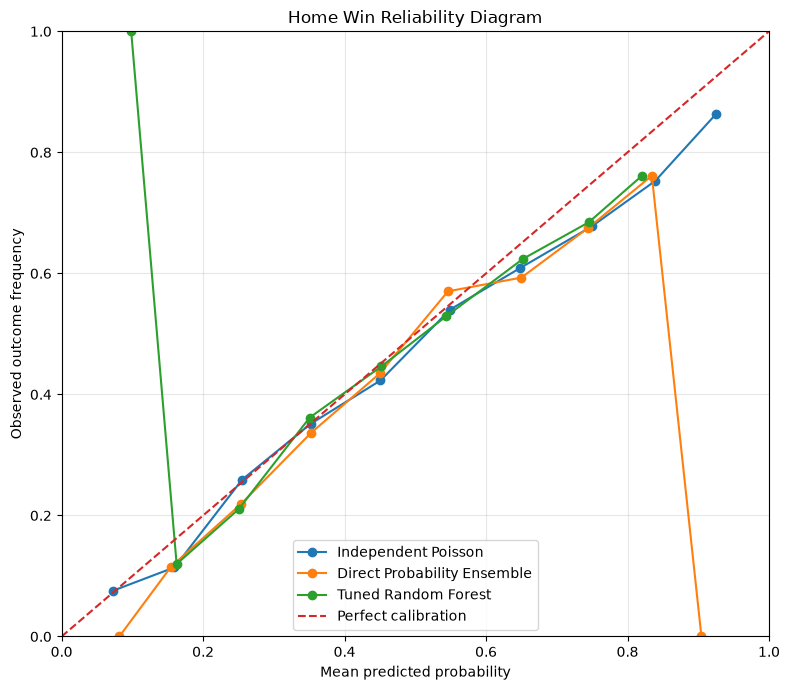

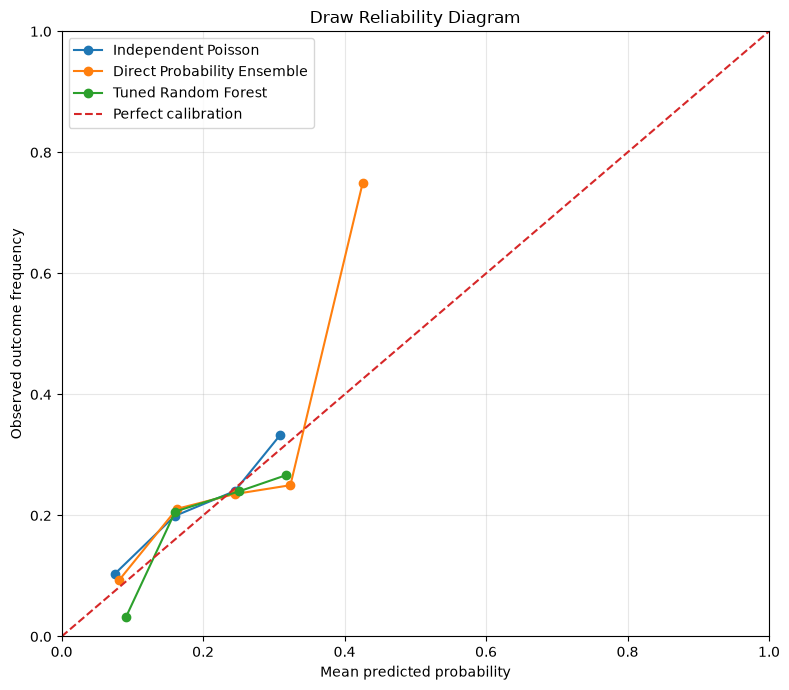

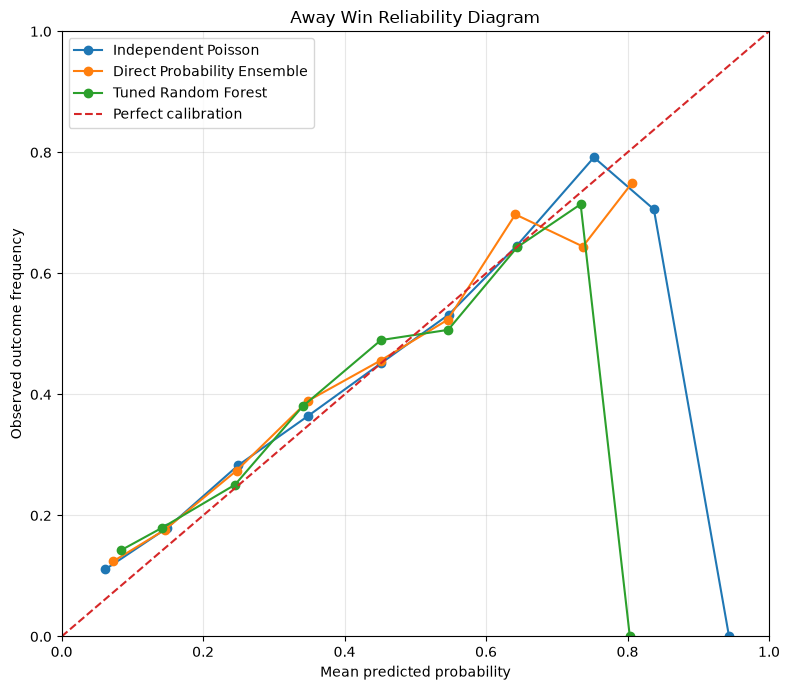

Bins containing fewer than 20 forecasts: 9

Largest observed calibration gaps:


,Model,Outcome,CalibrationBin,BinLowerBound,BinUpperBound,Forecasts,MeanPredictedProbability,ObservedFrequency,CalibrationGap,AbsoluteCalibrationGap
0,Independent Poisson,A,9,0.9,1.0,2,0.9435,0.0000,-0.9435,0.9435
1,Direct Probability Ensemble,H,9,0.9,1.0,1,0.9045,0.0000,-0.9045,0.9045
2,Tuned Random Forest,H,0,0.0,0.1,1,0.0983,1.0000,0.9017,0.9017
3,Tuned Random Forest,A,8,0.8,0.9,1,0.8033,0.0000,-0.8033,0.8033
4,Direct Probability Ensemble,D,4,0.4,0.5,4,0.4257,0.7500,0.3243,0.3243
5,Independent Poisson,A,8,0.8,0.9,17,0.8373,0.7059,-0.1314,0.1314
6,Direct Probability Ensemble,A,7,0.7,0.8,45,0.7369,0.6444,-0.0924,0.0924
7,Independent Poisson,H,8,0.8,0.9,89,0.8391,0.7528,-0.0863,0.0863
8,Direct Probability Ensemble,H,0,0.0,0.1,15,0.0816,0.0000,-0.0816,0.0816
9,Direct Probability Ensemble,D,3,0.3,0.4,112,0.3234,0.2500,-0.0734,0.0734


Sparsely populated bins:


,Model,Outcome,CalibrationBin,BinLowerBound,BinUpperBound,Forecasts,MeanPredictedProbability,ObservedFrequency,CalibrationGap,AbsoluteCalibrationGap
0,Independent Poisson,A,9,0.9,1.0,2,0.9435,0.0000,-0.9435,0.9435
1,Direct Probability Ensemble,H,9,0.9,1.0,1,0.9045,0.0000,-0.9045,0.9045
2,Tuned Random Forest,H,0,0.0,0.1,1,0.0983,1.0000,0.9017,0.9017
3,Tuned Random Forest,A,8,0.8,0.9,1,0.8033,0.0000,-0.8033,0.8033
4,Direct Probability Ensemble,D,4,0.4,0.5,4,0.4257,0.7500,0.3243,0.3243
5,Independent Poisson,A,8,0.8,0.9,17,0.8373,0.7059,-0.1314,0.1314
6,Direct Probability Ensemble,H,0,0.0,0.1,15,0.0816,0.0000,-0.0816,0.0816
7,Direct Probability Ensemble,A,8,0.8,0.9,4,0.8067,0.7500,-0.0567,0.0567
8,Independent Poisson,D,3,0.3,0.4,6,0.3093,0.3333,0.0241,0.0241


In [3]:
# ============================================================
# 4. Reliability Diagrams for the Leading Models
# ============================================================

import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Select the leading models
# ------------------------------------------------------------

LEADING_MODELS = [
    "Independent Poisson",
    "Direct Probability Ensemble",
    "Tuned Random Forest",
]


leading_calibration_bins = (
    baseline_calibration_bins.loc[
        baseline_calibration_bins[
            "Model"
        ].isin(
            LEADING_MODELS
        )
    ]
    .copy()
)


# ------------------------------------------------------------
# Display the detailed bin table
# ------------------------------------------------------------

leading_calibration_bin_table = (
    leading_calibration_bins[
        [
            "Model",
            "Outcome",
            "CalibrationBin",
            "BinLowerBound",
            "BinUpperBound",
            "Forecasts",
            "MeanPredictedProbability",
            "ObservedFrequency",
            "CalibrationGap",
            "AbsoluteCalibrationGap",
        ]
    ]
    .sort_values(
        by=[
            "Model",
            "Outcome",
            "CalibrationBin",
        ],
        kind="mergesort",
    )
    .reset_index(drop=True)
)


print(
    "Reliability data prepared successfully."
)

print(
    "Leading models:",
    LEADING_MODELS,
)

display(
    leading_calibration_bin_table.round(4)
)


# ------------------------------------------------------------
# Create one reliability diagram for each outcome
# ------------------------------------------------------------

outcome_names = {
    "H": "Home Win",
    "D": "Draw",
    "A": "Away Win",
}


for outcome in CLASS_ORDER:

    figure, axis = plt.subplots(
        figsize=(8, 7)
    )

    outcome_bin_data = (
        leading_calibration_bins.loc[
            leading_calibration_bins[
                "Outcome"
            ].eq(
                outcome
            )
        ]
    )

    for model_name in LEADING_MODELS:

        model_outcome_bins = (
            outcome_bin_data.loc[
                outcome_bin_data[
                    "Model"
                ].eq(
                    model_name
                )
            ]
            .sort_values(
                by="MeanPredictedProbability",
                kind="mergesort",
            )
        )

        axis.plot(
            model_outcome_bins[
                "MeanPredictedProbability"
            ],
            model_outcome_bins[
                "ObservedFrequency"
            ],
            marker="o",
            label=model_name,
        )

    axis.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Perfect calibration",
    )

    axis.set_xlim(
        0,
        1,
    )

    axis.set_ylim(
        0,
        1,
    )

    axis.set_xlabel(
        "Mean predicted probability"
    )

    axis.set_ylabel(
        "Observed outcome frequency"
    )

    axis.set_title(
        f"{outcome_names[outcome]} Reliability Diagram"
    )

    axis.grid(
        alpha=0.3
    )

    axis.legend()

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Identify sparsely populated and extreme-error bins
# ------------------------------------------------------------

sparse_bin_threshold = 20


sparse_calibration_bins = (
    leading_calibration_bin_table.loc[
        leading_calibration_bin_table[
            "Forecasts"
        ]
        <
        sparse_bin_threshold
    ]
    .sort_values(
        by="AbsoluteCalibrationGap",
        ascending=False,
        kind="mergesort",
    )
    .reset_index(drop=True)
)


largest_calibration_gaps = (
    leading_calibration_bin_table
    .sort_values(
        by="AbsoluteCalibrationGap",
        ascending=False,
        kind="mergesort",
    )
    .head(15)
    .reset_index(drop=True)
)


print(
    "Bins containing fewer than "
    f"{sparse_bin_threshold} forecasts:",
    len(
        sparse_calibration_bins
    ),
)

print(
    "\nLargest observed calibration gaps:"
)

display(
    largest_calibration_gaps.round(4)
)

print(
    "Sparsely populated bins:"
)

display(
    sparse_calibration_bins.round(4)
)

### Results and Interpretation

The reliability diagrams show that the three leading models are generally well calibrated throughout the probability ranges containing most forecasts.

For home wins, the reliability curves remain close to the perfect-calibration diagonal across the central probability range. Independent Poisson displays particularly consistent agreement between predicted probabilities and observed frequencies.

Draw probabilities are concentrated within a narrower range, primarily between approximately 10% and 35%. Within this region, the three models remain reasonably close to the calibration diagonal. Larger deviations at higher predicted draw probabilities should be interpreted cautiously because such forecasts are rare.

Away-win probabilities also track observed frequencies closely across the commonly populated probability range. Greater instability appears only in the most extreme probability bins.

Several reliability curves show sharp movements or vertical drops at probabilities above approximately 80%. These bins contain relatively few fixtures, meaning that one or two unexpected outcomes can produce a large observed calibration gap.

The large Maximum Calibration Error values are therefore driven partly by sparsely populated extreme-probability bins rather than broad systematic miscalibration.

The diagrams support the quantitative ECE results:

- Independent Poisson is the best-calibrated model on average;
- Random Forest and the ensemble remain broadly reliable;
- no leading model displays obvious systematic overconfidence or underconfidence throughout the main probability range;
- the greatest uncertainty occurs in rare, extreme-confidence forecasts.

The next stage will test whether chronological calibration methods can improve later unseen-season performance beyond these already strong original probabilities.

## 5. Define the Expanding-Window Calibration Folds

Probability calibration must preserve the chronological structure of the project.

The calibration models will not be fitted using the original model-training data. Instead, they will learn from the genuinely out-of-sample probability forecasts produced by the walk-forward backtest.

For each calibration fold:

1. earlier walk-forward seasons form the calibration-training sample;
2. the calibrator learns the relationship between predicted probabilities and observed outcomes;
3. the next complete season remains unseen;
4. the fitted calibrator is applied to that unseen season;
5. the calibration window then expands.

The calibration design is:

| Calibration-training seasons | Unseen evaluation season |
|---|---|
| 2020–21 | 2021–22 |
| 2020–21 to 2021–22 | 2022–23 |
| 2020–21 to 2022–23 | 2023–24 |
| 2020–21 to 2023–24 | 2024–25 |

The first season, 2020–21, is required to create the initial calibration-training sample. It therefore cannot also be used as a calibrated evaluation season.

The calibration comparison will initially focus on the three strongest walk-forward models:

1. Independent Poisson;
2. Direct Probability Ensemble;
3. Tuned Random Forest.

Each model will ultimately receive calibrated predictions for:

$$
4\times380=1,520
$$

unseen fixtures.

The original forecasting models will not be refitted in this notebook. Only their saved out-of-sample probabilities will be transformed.

In [4]:
# ============================================================
# 5. Define the Expanding-Window Calibration Folds
# ============================================================


# ------------------------------------------------------------
# Select the models included in the calibration experiment
# ------------------------------------------------------------

CALIBRATION_MODELS = [
    "Independent Poisson",
    "Direct Probability Ensemble",
    "Tuned Random Forest",
]


# ------------------------------------------------------------
# Define and validate chronological season order
# ------------------------------------------------------------

ordered_calibration_seasons = [
    "2020-21",
    "2021-22",
    "2022-23",
    "2023-24",
    "2024-25",
]


assert set(
    calibration_data[
        "EvaluationSeason"
    ].unique()
) == set(
    ordered_calibration_seasons
), (
    "The available walk-forward seasons do not match "
    "the intended calibration design."
)


assert set(
    CALIBRATION_MODELS
).issubset(
    set(
        calibration_data[
            "Model"
        ].unique()
    )
), (
    "At least one selected calibration model is missing "
    "from the probability dataset."
)


# ------------------------------------------------------------
# The first season trains the first calibrator
# ------------------------------------------------------------

calibration_evaluation_seasons = (
    ordered_calibration_seasons[1:]
)


assert calibration_evaluation_seasons == [
    "2021-22",
    "2022-23",
    "2023-24",
    "2024-25",
], (
    "Unexpected calibration evaluation seasons."
)


# ------------------------------------------------------------
# Construct the fold plan and model-level coverage tables
# ------------------------------------------------------------

calibration_fold_records = []
calibration_coverage_records = []


for fold_number, evaluation_season in enumerate(
    calibration_evaluation_seasons,
    start=1,
):

    evaluation_position = (
        ordered_calibration_seasons.index(
            evaluation_season
        )
    )

    training_seasons = (
        ordered_calibration_seasons[
            :evaluation_position
        ]
    )

    calibration_fold_records.append(
        {
            "Fold": fold_number,
            "CalibrationTrainingStart": (
                training_seasons[0]
            ),
            "CalibrationTrainingEnd": (
                training_seasons[-1]
            ),
            "CalibrationTrainingSeasons": len(
                training_seasons
            ),
            "TrainingForecastsPerModel": (
                len(training_seasons)
                * 380
            ),
            "EvaluationSeason": (
                evaluation_season
            ),
            "EvaluationForecastsPerModel": 380,
        }
    )

    for model_name in CALIBRATION_MODELS:

        model_training_data = (
            calibration_data.loc[
                calibration_data[
                    "Model"
                ].eq(model_name)
                &
                calibration_data[
                    "EvaluationSeason"
                ].isin(training_seasons)
            ]
            .copy()
        )

        model_evaluation_data = (
            calibration_data.loc[
                calibration_data[
                    "Model"
                ].eq(model_name)
                &
                calibration_data[
                    "EvaluationSeason"
                ].eq(evaluation_season)
            ]
            .copy()
        )

        expected_training_rows = (
            len(training_seasons)
            * 380
        )

        assert len(
            model_training_data
        ) == expected_training_rows, (
            f"{model_name}, fold {fold_number}: "
            "unexpected calibration-training row count."
        )

        assert len(
            model_evaluation_data
        ) == 380, (
            f"{model_name}, fold {fold_number}: "
            "expected 380 evaluation forecasts."
        )

        assert set(
            model_training_data[
                "ActualOutcome"
            ].unique()
        ) == set(CLASS_ORDER), (
            f"{model_name}, fold {fold_number}: "
            "the calibration-training data does not "
            "contain all three outcomes."
        )

        assert set(
            model_evaluation_data[
                "ActualOutcome"
            ].unique()
        ) == set(CLASS_ORDER), (
            f"{model_name}, fold {fold_number}: "
            "the evaluation season does not contain "
            "all three outcomes."
        )

        assert not model_training_data.duplicated(
            subset=fixture_key_columns
        ).any(), (
            f"{model_name}, fold {fold_number}: "
            "duplicate calibration-training fixtures."
        )

        assert not model_evaluation_data.duplicated(
            subset=fixture_key_columns
        ).any(), (
            f"{model_name}, fold {fold_number}: "
            "duplicate calibration-evaluation fixtures."
        )

        training_outcome_counts = (
            model_training_data[
                "ActualOutcome"
            ]
            .value_counts()
        )

        evaluation_outcome_counts = (
            model_evaluation_data[
                "ActualOutcome"
            ]
            .value_counts()
        )

        calibration_coverage_records.append(
            {
                "Fold": fold_number,
                "Model": model_name,
                "EvaluationSeason": (
                    evaluation_season
                ),
                "TrainingForecasts": len(
                    model_training_data
                ),
                "EvaluationForecasts": len(
                    model_evaluation_data
                ),
                "TrainingHomeWins": int(
                    training_outcome_counts.get(
                        "H",
                        0,
                    )
                ),
                "TrainingDraws": int(
                    training_outcome_counts.get(
                        "D",
                        0,
                    )
                ),
                "TrainingAwayWins": int(
                    training_outcome_counts.get(
                        "A",
                        0,
                    )
                ),
                "EvaluationHomeWins": int(
                    evaluation_outcome_counts.get(
                        "H",
                        0,
                    )
                ),
                "EvaluationDraws": int(
                    evaluation_outcome_counts.get(
                        "D",
                        0,
                    )
                ),
                "EvaluationAwayWins": int(
                    evaluation_outcome_counts.get(
                        "A",
                        0,
                    )
                ),
            }
        )


calibration_fold_plan = pd.DataFrame(
    calibration_fold_records
)


calibration_model_coverage = pd.DataFrame(
    calibration_coverage_records
)


# ------------------------------------------------------------
# Validate the completed fold structure
# ------------------------------------------------------------

assert len(
    calibration_fold_plan
) == 4, (
    "Expected four chronological calibration folds."
)


assert calibration_fold_plan[
    "TrainingForecastsPerModel"
].tolist() == [
    380,
    760,
    1140,
    1520,
], (
    "Unexpected expanding calibration-training sizes."
)


assert (
    calibration_fold_plan[
        "EvaluationForecastsPerModel"
    ]
    ==
    380
).all(), (
    "Every calibration evaluation fold should contain "
    "380 fixtures per model."
)


assert len(
    calibration_model_coverage
) == (
    len(CALIBRATION_MODELS)
    *
    len(calibration_evaluation_seasons)
), (
    "Unexpected model-fold coverage row count."
)


calibrated_evaluation_fixtures_per_model = int(
    calibration_fold_plan[
        "EvaluationForecastsPerModel"
    ].sum()
)


total_calibrated_model_forecasts = (
    calibrated_evaluation_fixtures_per_model
    *
    len(CALIBRATION_MODELS)
)


assert calibrated_evaluation_fixtures_per_model == 1520, (
    "Expected 1,520 calibrated evaluation fixtures per model."
)


assert total_calibrated_model_forecasts == 4560, (
    "Expected 4,560 calibrated model forecasts in total."
)


# ------------------------------------------------------------
# Display the calibration design
# ------------------------------------------------------------

print(
    "Expanding-window calibration folds "
    "created successfully."
)

print(
    "Calibration models:",
    len(CALIBRATION_MODELS),
)

print(
    "Calibration folds:",
    len(calibration_fold_plan),
)

print(
    "Unseen calibrated fixtures per model:",
    f"{calibrated_evaluation_fixtures_per_model:,}",
)

print(
    "Total model-evaluation forecasts:",
    f"{total_calibrated_model_forecasts:,}",
)

display(
    calibration_fold_plan
)

display(
    calibration_model_coverage
)

Expanding-window calibration folds created successfully.
Calibration models: 3
Calibration folds: 4
Unseen calibrated fixtures per model: 1,520
Total model-evaluation forecasts: 4,560


,Fold,CalibrationTrainingStart,CalibrationTrainingEnd,CalibrationTrainingSeasons,TrainingForecastsPerModel,EvaluationSeason,EvaluationForecastsPerModel
0,1,2020-21,2020-21,1,380,2021-22,380
1,2,2020-21,2021-22,2,760,2022-23,380
2,3,2020-21,2022-23,3,1140,2023-24,380
3,4,2020-21,2023-24,4,1520,2024-25,380


,Fold,Model,EvaluationSeason,TrainingForecasts,EvaluationForecasts,TrainingHomeWins,TrainingDraws,TrainingAwayWins,EvaluationHomeWins,EvaluationDraws,EvaluationAwayWins
0,1,Independent Poisson,2021-22,380,380,144,83,153,163,88,129
1,1,Direct Probability Ensemble,2021-22,380,380,144,83,153,163,88,129
2,1,Tuned Random Forest,2021-22,380,380,144,83,153,163,88,129
3,2,Independent Poisson,2022-23,760,380,307,171,282,184,87,109
4,2,Direct Probability Ensemble,2022-23,760,380,307,171,282,184,87,109
5,2,Tuned Random Forest,2022-23,760,380,307,171,282,184,87,109
6,3,Independent Poisson,2023-24,1140,380,491,258,391,175,82,123
7,3,Direct Probability Ensemble,2023-24,1140,380,491,258,391,175,82,123
8,3,Tuned Random Forest,2023-24,1140,380,491,258,391,175,82,123
9,4,Independent Poisson,2024-25,1520,380,666,340,514,155,93,132


## 6. Apply Expanding-Window Probability Calibration

Two calibration methods will be tested.

### Sigmoid Calibration

Sigmoid calibration fits a logistic relationship between the original predicted probability and the observed binary outcome.

For each outcome $k$, the original probability is first converted into log-odds:

$$
z_{i,k}
=
\log\left(
\frac{\hat{p}_{i,k}}
{1-\hat{p}_{i,k}}
\right).
$$

A binary logistic regression then estimates:

$$
\tilde{p}_{i,k}
=
\frac{1}
{1+\exp\left[-(a_kz_{i,k}+b_k)\right]}.
$$

This produces a smooth parametric adjustment. It can reduce systematic overconfidence or underconfidence while generally preserving the ordering of forecasts.

### Isotonic Calibration

Isotonic regression learns a non-decreasing relationship between the original predicted probability and the observed outcome frequency.

Unlike sigmoid calibration, isotonic regression does not impose a fixed functional form. It can therefore learn more flexible calibration curves, but it may overfit when the available calibration sample is small.

### Multiclass Renormalisation

Sigmoid and isotonic calibration are applied separately to:

- home-win probabilities;
- draw probabilities;
- away-win probabilities.

The three independently calibrated values may not initially sum to one. They will therefore be renormalised:

$$
P_k^{*}
=
\frac{\tilde{P}_k}
{\tilde{P}_H+\tilde{P}_D+\tilde{P}_A}.
$$

Each evaluation season will receive three probability versions:

1. original probabilities;
2. sigmoid-calibrated probabilities;
3. isotonic-calibrated probabilities.

Every calibrator will be fitted using earlier walk-forward seasons only.

In [5]:
# ============================================================
# 6. Apply Expanding-Window Probability Calibration
# ============================================================

from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression


# ------------------------------------------------------------
# Calibration settings
# ------------------------------------------------------------

CALIBRATION_METHODS = [
    "Original",
    "Sigmoid",
    "Isotonic",
]

SIGMOID_INPUT_EPSILON = 1e-6
OUTPUT_PROBABILITY_EPSILON = 1e-12


# ------------------------------------------------------------
# Convert probabilities into log-odds
# ------------------------------------------------------------

def probability_to_log_odds(
    probabilities,
):
    """
    Convert probabilities into finite log-odds values.
    """

    probabilities = np.asarray(
        probabilities,
        dtype=float,
    )

    clipped_probabilities = np.clip(
        probabilities,
        SIGMOID_INPUT_EPSILON,
        1.0 - SIGMOID_INPUT_EPSILON,
    )

    log_odds = np.log(
        clipped_probabilities
        /
        (
            1.0
            -
            clipped_probabilities
        )
    )

    return log_odds.reshape(
        -1,
        1,
    )


# ------------------------------------------------------------
# Fit one-vs-rest calibrators
# ------------------------------------------------------------

def fit_outcome_calibrators(
    training_forecasts,
    calibration_method,
):
    """
    Fit one calibrator for each H/D/A outcome.
    """

    assert calibration_method in {
        "Sigmoid",
        "Isotonic",
    }, (
        "Only Sigmoid and Isotonic calibrators "
        "can be fitted."
    )

    fitted_calibrators = {}

    for outcome in CLASS_ORDER:

        probability_column = (
            f"Probability_{outcome}"
        )

        original_probabilities = (
            training_forecasts[
                probability_column
            ]
            .to_numpy(
                dtype=float
            )
        )

        binary_outcomes = (
            training_forecasts[
                "ActualOutcome"
            ]
            .eq(outcome)
            .astype(int)
            .to_numpy()
        )

        assert set(
            np.unique(
                binary_outcomes
            )
        ) == {
            0,
            1,
        }, (
            f"{outcome}: calibration training data "
            "must contain positive and negative examples."
        )

        if calibration_method == "Sigmoid":

            calibrator = LogisticRegression(
                penalty="l2",
                C=1_000_000.0,
                solver="lbfgs",
                max_iter=5000,
            )

            calibrator.fit(
                probability_to_log_odds(
                    original_probabilities
                ),
                binary_outcomes,
            )

        else:

            calibrator = IsotonicRegression(
                y_min=0.0,
                y_max=1.0,
                increasing=True,
                out_of_bounds="clip",
            )

            calibrator.fit(
                original_probabilities,
                binary_outcomes,
            )

        fitted_calibrators[
            outcome
        ] = calibrator

    return fitted_calibrators


# ------------------------------------------------------------
# Apply one-vs-rest calibrators and renormalise
# ------------------------------------------------------------

def apply_outcome_calibrators(
    evaluation_forecasts,
    fitted_calibrators,
    calibration_method,
):
    """
    Apply outcome-specific calibrators and renormalise
    the resulting H/D/A probabilities.
    """

    calibrated_columns = []

    for outcome in CLASS_ORDER:

        probability_column = (
            f"Probability_{outcome}"
        )

        original_probabilities = (
            evaluation_forecasts[
                probability_column
            ]
            .to_numpy(
                dtype=float
            )
        )

        calibrator = (
            fitted_calibrators[
                outcome
            ]
        )

        if calibration_method == "Sigmoid":

            calibrated_probabilities = (
                calibrator.predict_proba(
                    probability_to_log_odds(
                        original_probabilities
                    )
                )
                [
                    :,
                    1,
                ]
            )

        elif calibration_method == "Isotonic":

            calibrated_probabilities = (
                calibrator.predict(
                    original_probabilities
                )
            )

        else:

            raise ValueError(
                "Unexpected calibration method: "
                f"{calibration_method}"
            )

        calibrated_columns.append(
            calibrated_probabilities
        )

    calibrated_probability_matrix = (
        np.column_stack(
            calibrated_columns
        )
    )

    calibrated_probability_matrix = np.clip(
        calibrated_probability_matrix,
        OUTPUT_PROBABILITY_EPSILON,
        1.0 - OUTPUT_PROBABILITY_EPSILON,
    )

    probability_totals = (
        calibrated_probability_matrix.sum(
            axis=1,
            keepdims=True,
        )
    )

    assert (
        probability_totals
        >
        0
    ).all(), (
        "A calibrated probability row has "
        "zero total probability."
    )

    calibrated_probability_matrix = (
        calibrated_probability_matrix
        /
        probability_totals
    )

    validate_probability_matrix(
        calibrated_probability_matrix,
        (
            f"{calibration_method} calibrated "
            "probabilities"
        ),
    )

    return calibrated_probability_matrix


# ------------------------------------------------------------
# Storage for fold-level and fixture-level outputs
# ------------------------------------------------------------

calibration_metric_records = []
calibrated_prediction_frames = []
calibrator_diagnostic_records = []


# ------------------------------------------------------------
# Execute the expanding-window calibration backtest
# ------------------------------------------------------------

for fold_number, evaluation_season in enumerate(
    calibration_evaluation_seasons,
    start=1,
):

    evaluation_position = (
        ordered_calibration_seasons.index(
            evaluation_season
        )
    )

    calibration_training_seasons = (
        ordered_calibration_seasons[
            :evaluation_position
        ]
    )

    print(
        f"Starting calibration fold {fold_number} of "
        f"{len(calibration_evaluation_seasons)}: "
        f"evaluating {evaluation_season}"
    )

    for model_name in CALIBRATION_MODELS:

        training_forecasts = (
            calibration_data.loc[
                calibration_data[
                    "Model"
                ].eq(
                    model_name
                )
                &
                calibration_data[
                    "EvaluationSeason"
                ].isin(
                    calibration_training_seasons
                )
            ]
            .sort_values(
                by=fixture_key_columns,
                kind="mergesort",
            )
            .reset_index(drop=True)
        )

        evaluation_forecasts = (
            calibration_data.loc[
                calibration_data[
                    "Model"
                ].eq(
                    model_name
                )
                &
                calibration_data[
                    "EvaluationSeason"
                ].eq(
                    evaluation_season
                )
            ]
            .sort_values(
                by=fixture_key_columns,
                kind="mergesort",
            )
            .reset_index(drop=True)
        )

        expected_training_rows = (
            len(
                calibration_training_seasons
            )
            *
            380
        )

        assert len(
            training_forecasts
        ) == expected_training_rows, (
            f"{model_name}, {evaluation_season}: "
            "unexpected calibration-training size."
        )

        assert len(
            evaluation_forecasts
        ) == 380, (
            f"{model_name}, {evaluation_season}: "
            "expected 380 evaluation forecasts."
        )

        original_probability_matrix = (
            evaluation_forecasts[
                PROBABILITY_COLUMNS
            ]
            .to_numpy(
                dtype=float
            )
        )

        validate_probability_matrix(
            original_probability_matrix,
            (
                f"{model_name}, {evaluation_season}, "
                "original"
            ),
        )

        probability_versions = {
            "Original": (
                original_probability_matrix
            ),
        }

        # ----------------------------------------------------
        # Fit and apply each calibration method
        # ----------------------------------------------------

        for calibration_method in [
            "Sigmoid",
            "Isotonic",
        ]:

            fitted_calibrators = (
                fit_outcome_calibrators(
                    training_forecasts=(
                        training_forecasts
                    ),
                    calibration_method=(
                        calibration_method
                    ),
                )
            )

            calibrated_probability_matrix = (
                apply_outcome_calibrators(
                    evaluation_forecasts=(
                        evaluation_forecasts
                    ),
                    fitted_calibrators=(
                        fitted_calibrators
                    ),
                    calibration_method=(
                        calibration_method
                    ),
                )
            )

            probability_versions[
                calibration_method
            ] = calibrated_probability_matrix

            # ------------------------------------------------
            # Store calibrator diagnostics
            # ------------------------------------------------

            for outcome in CLASS_ORDER:

                fitted_calibrator = (
                    fitted_calibrators[
                        outcome
                    ]
                )

                diagnostic_record = {
                    "Fold": fold_number,
                    "Model": model_name,
                    "CalibrationMethod": (
                        calibration_method
                    ),
                    "Outcome": outcome,
                    "TrainingStartSeason": (
                        calibration_training_seasons[
                            0
                        ]
                    ),
                    "TrainingEndSeason": (
                        calibration_training_seasons[
                            -1
                        ]
                    ),
                    "TrainingForecasts": len(
                        training_forecasts
                    ),
                    "EvaluationSeason": (
                        evaluation_season
                    ),
                }

                if calibration_method == "Sigmoid":

                    diagnostic_record[
                        "SigmoidCoefficient"
                    ] = float(
                        fitted_calibrator.coef_[
                            0,
                            0,
                        ]
                    )

                    diagnostic_record[
                        "SigmoidIntercept"
                    ] = float(
                        fitted_calibrator.intercept_[
                            0
                        ]
                    )

                    diagnostic_record[
                        "IsotonicThresholds"
                    ] = np.nan

                else:

                    diagnostic_record[
                        "SigmoidCoefficient"
                    ] = np.nan

                    diagnostic_record[
                        "SigmoidIntercept"
                    ] = np.nan

                    diagnostic_record[
                        "IsotonicThresholds"
                    ] = int(
                        len(
                            fitted_calibrator.X_thresholds_
                        )
                    )

                calibrator_diagnostic_records.append(
                    diagnostic_record
                )

        # ----------------------------------------------------
        # Evaluate and store every probability version
        # ----------------------------------------------------

        for (
            calibration_method,
            probability_matrix,
        ) in probability_versions.items():

            predicted_outcomes = (
                np.array(
                    CLASS_ORDER
                )
                [
                    probability_matrix.argmax(
                        axis=1
                    )
                ]
            )

            calibration_metric_records.append(
                {
                    "Fold": fold_number,
                    "Model": model_name,
                    "CalibrationMethod": (
                        calibration_method
                    ),
                    "CalibrationTrainingStart": (
                        calibration_training_seasons[
                            0
                        ]
                    ),
                    "CalibrationTrainingEnd": (
                        calibration_training_seasons[
                            -1
                        ]
                    ),
                    "CalibrationTrainingForecasts": (
                        len(
                            training_forecasts
                        )
                    ),
                    "EvaluationSeason": (
                        evaluation_season
                    ),
                    "EvaluationFixtures": len(
                        evaluation_forecasts
                    ),
                    "LogLoss": (
                        calculate_multiclass_log_loss(
                            evaluation_forecasts[
                                "ActualOutcome"
                            ],
                            probability_matrix,
                        )
                    ),
                    "BrierScore": (
                        calculate_multiclass_brier_score(
                            evaluation_forecasts[
                                "ActualOutcome"
                            ],
                            probability_matrix,
                        )
                    ),
                    "Accuracy": accuracy_score(
                        evaluation_forecasts[
                            "ActualOutcome"
                        ],
                        predicted_outcomes,
                    ),
                    "MeanMaximumProbability": float(
                        probability_matrix.max(
                            axis=1
                        ).mean()
                    ),
                }
            )

            fixture_output = (
                evaluation_forecasts[
                    fixture_key_columns
                    + [
                        "EvaluationSeason",
                        "ActualOutcome",
                    ]
                ]
                .copy()
            )

            fixture_output[
                "Fold"
            ] = fold_number

            fixture_output[
                "Model"
            ] = model_name

            fixture_output[
                "CalibrationMethod"
            ] = calibration_method

            fixture_output[
                "CalibrationTrainingStart"
            ] = calibration_training_seasons[
                0
            ]

            fixture_output[
                "CalibrationTrainingEnd"
            ] = calibration_training_seasons[
                -1
            ]

            fixture_output[
                "PredictedOutcome"
            ] = predicted_outcomes

            for outcome_position, outcome in enumerate(
                CLASS_ORDER
            ):

                fixture_output[
                    f"Probability_{outcome}"
                ] = probability_matrix[
                    :,
                    outcome_position,
                ]

            calibrated_prediction_frames.append(
                fixture_output
            )

    print(
        f"Completed calibration fold {fold_number}: "
        f"{evaluation_season}"
    )


# ------------------------------------------------------------
# Combine the outputs
# ------------------------------------------------------------

calibration_fold_metrics = pd.DataFrame(
    calibration_metric_records
)

calibrated_predictions = pd.concat(
    calibrated_prediction_frames,
    ignore_index=True,
)

calibrator_diagnostics = pd.DataFrame(
    calibrator_diagnostic_records
)


# ------------------------------------------------------------
# Validate the completed calibration experiment
# ------------------------------------------------------------

expected_metric_rows = (
    len(
        CALIBRATION_MODELS
    )
    *
    len(
        calibration_evaluation_seasons
    )
    *
    len(
        CALIBRATION_METHODS
    )
)

expected_prediction_rows = (
    expected_metric_rows
    *
    380
)

expected_diagnostic_rows = (
    len(
        CALIBRATION_MODELS
    )
    *
    len(
        calibration_evaluation_seasons
    )
    *
    2
    *
    len(
        CLASS_ORDER
    )
)


assert len(
    calibration_fold_metrics
) == expected_metric_rows == 36, (
    "Expected 36 fold-level calibration metric rows."
)


assert len(
    calibrated_predictions
) == expected_prediction_rows == 13680, (
    "Expected 13,680 calibrated fixture forecasts."
)


assert len(
    calibrator_diagnostics
) == expected_diagnostic_rows == 72, (
    "Expected 72 fitted-calibrator diagnostic rows."
)


assert not calibrated_predictions.duplicated(
    subset=(
        fixture_key_columns
        + [
            "Model",
            "CalibrationMethod",
        ]
    )
).any(), (
    "Duplicate calibrated fixture forecasts were detected."
)


assert np.allclose(
    calibrated_predictions[
        PROBABILITY_COLUMNS
    ].sum(
        axis=1
    ),
    1.0,
    atol=1e-8,
), (
    "At least one calibrated probability row "
    "does not sum to one."
)


method_row_counts = (
    calibrated_predictions[
        "CalibrationMethod"
    ]
    .value_counts()
)


assert (
    method_row_counts
    ==
    4560
).all(), (
    "Each probability method should contain "
    "4,560 fixture-model forecasts."
)


# ------------------------------------------------------------
# Display the first results
# ------------------------------------------------------------

print(
    "Expanding-window probability calibration "
    "completed successfully."
)

print(
    "Fold-level metric rows:",
    f"{len(calibration_fold_metrics):,}",
)

print(
    "Fixture-level probability rows:",
    f"{len(calibrated_predictions):,}",
)

print(
    "Calibrator diagnostic rows:",
    f"{len(calibrator_diagnostics):,}",
)

display(
    calibration_fold_metrics
    .sort_values(
        by=[
            "EvaluationSeason",
            "Model",
            "LogLoss",
        ],
        kind="mergesort",
    )
    .reset_index(drop=True)
    .round(6)
)

Starting calibration fold 1 of 4: evaluating 2021-22


c:\Users\kiera\OneDrive\Desktop\premier-league-probability-engine\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\kiera\OneDrive\Desktop\premier-league-probability-engine\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of

Completed calibration fold 1: 2021-22
Starting calibration fold 2 of 4: evaluating 2022-23


c:\Users\kiera\OneDrive\Desktop\premier-league-probability-engine\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\kiera\OneDrive\Desktop\premier-league-probability-engine\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of

Completed calibration fold 2: 2022-23
Starting calibration fold 3 of 4: evaluating 2023-24


c:\Users\kiera\OneDrive\Desktop\premier-league-probability-engine\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\kiera\OneDrive\Desktop\premier-league-probability-engine\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of

Completed calibration fold 3: 2023-24
Starting calibration fold 4 of 4: evaluating 2024-25


c:\Users\kiera\OneDrive\Desktop\premier-league-probability-engine\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\kiera\OneDrive\Desktop\premier-league-probability-engine\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of

Completed calibration fold 4: 2024-25
Expanding-window probability calibration completed successfully.
Fold-level metric rows: 36
Fixture-level probability rows: 13,680
Calibrator diagnostic rows: 72


,Fold,Model,CalibrationMethod,CalibrationTrainingStart,CalibrationTrainingEnd,CalibrationTrainingForecasts,EvaluationSeason,EvaluationFixtures,LogLoss,BrierScore,Accuracy,MeanMaximumProbability
0,1,Direct Probability Ensemble,Original,2020-21,2020-21,380,2021-22,380,0.973540,0.578422,0.550000,0.553054
1,1,Direct Probability Ensemble,Sigmoid,2020-21,2020-21,380,2021-22,380,0.998633,0.595727,0.500000,0.521327
2,1,Direct Probability Ensemble,Isotonic,2020-21,2020-21,380,2021-22,380,1.013891,0.605793,0.518421,0.564742
3,1,Independent Poisson,Original,2020-21,2020-21,380,2021-22,380,0.965925,0.574944,0.550000,0.555788
4,1,Independent Poisson,Sigmoid,2020-21,2020-21,380,2021-22,380,0.993552,0.593100,0.492105,0.512423
5,1,Independent Poisson,Isotonic,2020-21,2020-21,380,2021-22,380,1.010761,0.604231,0.486842,0.559030
6,1,Tuned Random Forest,Original,2020-21,2020-21,380,2021-22,380,0.972121,0.576253,0.547368,0.554903
7,1,Tuned Random Forest,Isotonic,2020-21,2020-21,380,2021-22,380,0.990913,0.591693,0.534211,0.556585
8,1,Tuned Random Forest,Sigmoid,2020-21,2020-21,380,2021-22,380,0.999318,0.595466,0.515789,0.524542
9,2,Direct Probability Ensemble,Original,2020-21,2021-22,760,2022-23,380,0.974600,0.580064,0.539474,0.547760


## 7. Compare Original and Calibrated Predictive Performance

The expanding-window experiment produced original, sigmoid-calibrated and isotonic-calibrated probabilities for the same 1,520 unseen fixtures per model.

This section compares the three probability versions using:

- multiclass log loss;
- multiclass Brier score;
- classification accuracy;
- mean maximum predicted probability;
- season-by-season performance.

For each model and calibration method, the change in log loss is defined as:

$$
\Delta L
=
L_{\text{calibrated}}
-
L_{\text{original}}.
$$

Therefore:

- $\Delta L<0$ indicates that calibration improved log loss;
- $\Delta L>0$ indicates that calibration made log loss worse.

The percentage improvement relative to the original forecast is:

$$
100
\times
\frac{
L_{\text{original}}
-
L_{\text{calibrated}}
}{
L_{\text{original}}
}.
$$

Calibration should only be retained if it improves genuinely unseen forecasts. Better apparent fit on the historical calibration sample is not sufficient.

In [6]:
# ============================================================
# 7. Compare Original and Calibrated Predictive Performance
# ============================================================


# ------------------------------------------------------------
# Calculate aggregate metrics directly from fixture forecasts
# ------------------------------------------------------------

aggregate_calibration_records = []


for (
    model_name,
    calibration_method,
), method_forecasts in calibrated_predictions.groupby(
    [
        "Model",
        "CalibrationMethod",
    ],
    sort=False,
):

    method_forecasts = (
        method_forecasts
        .sort_values(
            by=fixture_key_columns,
            kind="mergesort",
        )
        .reset_index(drop=True)
    )

    probability_matrix = (
        method_forecasts[
            PROBABILITY_COLUMNS
        ]
        .to_numpy(
            dtype=float
        )
    )

    validate_probability_matrix(
        probability_matrix,
        (
            f"{model_name}, "
            f"{calibration_method}"
        ),
    )

    predicted_outcomes = (
        np.array(
            CLASS_ORDER
        )[
            probability_matrix.argmax(
                axis=1
            )
        ]
    )

    aggregate_calibration_records.append(
        {
            "Model": model_name,
            "CalibrationMethod": (
                calibration_method
            ),
            "Fixtures": len(
                method_forecasts
            ),
            "LogLoss": (
                calculate_multiclass_log_loss(
                    method_forecasts[
                        "ActualOutcome"
                    ],
                    probability_matrix,
                )
            ),
            "BrierScore": (
                calculate_multiclass_brier_score(
                    method_forecasts[
                        "ActualOutcome"
                    ],
                    probability_matrix,
                )
            ),
            "Accuracy": accuracy_score(
                method_forecasts[
                    "ActualOutcome"
                ],
                predicted_outcomes,
            ),
            "MeanMaximumProbability": float(
                probability_matrix.max(
                    axis=1
                ).mean()
            ),
        }
    )


aggregate_calibration_comparison = pd.DataFrame(
    aggregate_calibration_records
)


# ------------------------------------------------------------
# Attach each model's original performance
# ------------------------------------------------------------

original_method_metrics = (
    aggregate_calibration_comparison.loc[
        aggregate_calibration_comparison[
            "CalibrationMethod"
        ].eq(
            "Original"
        ),
        [
            "Model",
            "LogLoss",
            "BrierScore",
        ],
    ]
    .rename(
        columns={
            "LogLoss": "OriginalLogLoss",
            "BrierScore": "OriginalBrierScore",
        }
    )
)


aggregate_calibration_comparison = (
    aggregate_calibration_comparison
    .merge(
        original_method_metrics,
        on="Model",
        how="left",
        validate="many_to_one",
    )
)


# ------------------------------------------------------------
# Calculate improvement relative to original forecasts
# ------------------------------------------------------------

aggregate_calibration_comparison[
    "LogLossChange"
] = (
    aggregate_calibration_comparison[
        "LogLoss"
    ]
    -
    aggregate_calibration_comparison[
        "OriginalLogLoss"
    ]
)


aggregate_calibration_comparison[
    "LogLossImprovementPercent"
] = (
    100
    *
    (
        aggregate_calibration_comparison[
            "OriginalLogLoss"
        ]
        -
        aggregate_calibration_comparison[
            "LogLoss"
        ]
    )
    /
    aggregate_calibration_comparison[
        "OriginalLogLoss"
    ]
)


aggregate_calibration_comparison[
    "BrierScoreChange"
] = (
    aggregate_calibration_comparison[
        "BrierScore"
    ]
    -
    aggregate_calibration_comparison[
        "OriginalBrierScore"
    ]
)


aggregate_calibration_comparison[
    "ImprovedLogLoss"
] = (
    aggregate_calibration_comparison[
        "LogLossChange"
    ]
    <
    0
)


# ------------------------------------------------------------
# Rank all model-method combinations
# ------------------------------------------------------------

aggregate_calibration_comparison = (
    aggregate_calibration_comparison
    .sort_values(
        by=[
            "LogLoss",
            "BrierScore",
        ],
        ascending=[
            True,
            True,
        ],
        kind="mergesort",
    )
    .reset_index(drop=True)
)


aggregate_calibration_comparison.insert(
    0,
    "OverallRank",
    np.arange(
        1,
        len(
            aggregate_calibration_comparison
        )
        + 1,
    ),
)


# ------------------------------------------------------------
# Identify the best method for each model
# ------------------------------------------------------------

best_method_by_model = (
    aggregate_calibration_comparison
    .sort_values(
        by=[
            "Model",
            "LogLoss",
        ],
        kind="mergesort",
    )
    .groupby(
        "Model",
        as_index=False,
        sort=False,
    )
    .first()
    [
        [
            "Model",
            "CalibrationMethod",
            "LogLoss",
            "BrierScore",
            "Accuracy",
            "LogLossChange",
            "LogLossImprovementPercent",
        ]
    ]
    .rename(
        columns={
            "CalibrationMethod": (
                "BestCalibrationMethod"
            ),
            "LogLoss": "BestLogLoss",
            "BrierScore": "BestBrierScore",
            "Accuracy": "BestAccuracy",
        }
    )
)


# ------------------------------------------------------------
# Create season-by-season method comparison
# ------------------------------------------------------------

seasonal_calibration_comparison = (
    calibration_fold_metrics[
        [
            "EvaluationSeason",
            "Model",
            "CalibrationMethod",
            "LogLoss",
            "BrierScore",
            "Accuracy",
        ]
    ]
    .sort_values(
        by=[
            "EvaluationSeason",
            "Model",
            "LogLoss",
        ],
        kind="mergesort",
    )
    .reset_index(drop=True)
)


seasonal_method_winners = (
    seasonal_calibration_comparison
    .sort_values(
        by=[
            "Model",
            "EvaluationSeason",
            "LogLoss",
        ],
        kind="mergesort",
    )
    .groupby(
        [
            "Model",
            "EvaluationSeason",
        ],
        as_index=False,
        sort=False,
    )
    .first()
    .rename(
        columns={
            "CalibrationMethod": (
                "WinningCalibrationMethod"
            ),
            "LogLoss": "WinningLogLoss",
            "BrierScore": "WinningBrierScore",
            "Accuracy": "WinningAccuracy",
        }
    )
)


method_win_counts = (
    seasonal_method_winners
    .groupby(
        [
            "Model",
            "WinningCalibrationMethod",
        ],
        as_index=False,
    )
    .size()
    .rename(
        columns={
            "size": "SeasonsWon",
        }
    )
)


# ------------------------------------------------------------
# Validate the comparison
# ------------------------------------------------------------

assert len(
    aggregate_calibration_comparison
) == 9, (
    "Expected three probability methods for "
    "each of three models."
)


assert (
    aggregate_calibration_comparison[
        "Fixtures"
    ]
    ==
    1520
).all(), (
    "Every model-method combination should contain "
    "1,520 unseen fixtures."
)


assert len(
    best_method_by_model
) == 3, (
    "Expected one selected method for each model."
)


assert len(
    seasonal_method_winners
) == 12, (
    "Expected one winning method for each "
    "model-season combination."
)


# ------------------------------------------------------------
# Display the results
# ------------------------------------------------------------

leading_probability_version = (
    aggregate_calibration_comparison.iloc[0]
)


print(
    "Original and calibrated performance "
    "comparison completed successfully."
)

print(
    "Leading model-method combination:",
    leading_probability_version[
        "Model"
    ],
    "-",
    leading_probability_version[
        "CalibrationMethod"
    ],
)

print(
    "Leading log loss:",
    round(
        float(
            leading_probability_version[
                "LogLoss"
            ]
        ),
        6,
    ),
)

display(
    aggregate_calibration_comparison[
        [
            "OverallRank",
            "Model",
            "CalibrationMethod",
            "Fixtures",
            "LogLoss",
            "LogLossChange",
            "LogLossImprovementPercent",
            "BrierScore",
            "BrierScoreChange",
            "Accuracy",
            "MeanMaximumProbability",
            "ImprovedLogLoss",
        ]
    ].round(6)
)

print(
    "Best probability method for each model:"
)

display(
    best_method_by_model.round(6)
)

print(
    "Winning calibration method by model and season:"
)

display(
    seasonal_method_winners.round(6)
)

print(
    "Seasonal method win counts:"
)

display(
    method_win_counts
)

Original and calibrated performance comparison completed successfully.
Leading model-method combination: Independent Poisson - Original
Leading log loss: 0.964879


,OverallRank,Model,CalibrationMethod,Fixtures,LogLoss,LogLossChange,LogLossImprovementPercent,BrierScore,BrierScoreChange,Accuracy,MeanMaximumProbability,ImprovedLogLoss
0,1,Independent Poisson,Original,1520,0.964879,0.000000,0.000000,0.573900,0.000000,0.546053,0.556570,False
1,2,Direct Probability Ensemble,Original,1520,0.968902,0.000000,0.000000,0.575592,0.000000,0.548026,0.554670,False
2,3,Tuned Random Forest,Original,1520,0.971097,0.000000,0.000000,0.576400,0.000000,0.548026,0.556786,False
3,4,Independent Poisson,Sigmoid,1520,0.979152,0.014273,-1.479202,0.582928,0.009028,0.526974,0.520693,False
4,5,Direct Probability Ensemble,Sigmoid,1520,0.981674,0.012773,-1.318280,0.584110,0.008518,0.536842,0.524178,False
5,6,Tuned Random Forest,Sigmoid,1520,0.983888,0.012791,-1.317135,0.585053,0.008653,0.535526,0.528376,False
6,7,Independent Poisson,Isotonic,1520,0.988119,0.023239,-2.408512,0.588018,0.014118,0.526974,0.548511,False
7,8,Direct Probability Ensemble,Isotonic,1520,1.022542,0.053640,-5.536202,0.588507,0.012915,0.540789,0.551314,False
8,9,Tuned Random Forest,Isotonic,1520,1.048426,0.077328,-7.963000,0.586228,0.009828,0.536184,0.551734,False


Best probability method for each model:


,Model,BestCalibrationMethod,BestLogLoss,BestBrierScore,BestAccuracy,LogLossChange,LogLossImprovementPercent
0,Direct Probability Ensemble,Original,0.968902,0.575592,0.548026,0.0,0.0
1,Independent Poisson,Original,0.964879,0.573900,0.546053,0.0,0.0
2,Tuned Random Forest,Original,0.971097,0.576400,0.548026,0.0,0.0


Winning calibration method by model and season:


,Model,EvaluationSeason,WinningCalibrationMethod,WinningLogLoss,WinningBrierScore,WinningAccuracy
0,Direct Probability Ensemble,2021-22,Original,0.973540,0.578422,0.550000
1,Direct Probability Ensemble,2022-23,Original,0.974600,0.580064,0.539474
2,Direct Probability Ensemble,2023-24,Original,0.931185,0.548000,0.584211
3,Direct Probability Ensemble,2024-25,Sigmoid,0.988872,0.590803,0.523684
4,Independent Poisson,2021-22,Original,0.965925,0.574944,0.550000
5,Independent Poisson,2022-23,Original,0.979675,0.582740,0.547368
6,Independent Poisson,2023-24,Original,0.924724,0.545239,0.584211
7,Independent Poisson,2024-25,Sigmoid,0.985825,0.589167,0.513158
8,Tuned Random Forest,2021-22,Original,0.972121,0.576253,0.547368
9,Tuned Random Forest,2022-23,Original,0.977768,0.581453,0.539474


Seasonal method win counts:


,Model,WinningCalibrationMethod,SeasonsWon
0,Direct Probability Ensemble,Original,3
1,Direct Probability Ensemble,Sigmoid,1
2,Independent Poisson,Original,3
3,Independent Poisson,Sigmoid,1
4,Tuned Random Forest,Original,3
5,Tuned Random Forest,Sigmoid,1


### Results and Interpretation

The chronological calibration experiment showed that the original probability distributions remained stronger than their calibrated alternatives.

Across the 1,520 common unseen fixtures, the three leading original models achieved:

| Model | Method | Log loss |
|---|---|---:|
| Independent Poisson | Original | 0.964879 |
| Direct Probability Ensemble | Original | 0.968902 |
| Tuned Random Forest | Original | 0.971097 |

Independent Poisson therefore remained the leading probability model on the common calibration-evaluation period.

Neither sigmoid nor isotonic calibration improved aggregate log loss.

For Independent Poisson, sigmoid calibration increased log loss from 0.964879 to 0.979152:

$$
\Delta L
=
0.979152-0.964879
=
0.014273.
$$

This represents a deterioration of approximately 1.48%.

The calibrated Poisson probabilities also produced a worse Brier score, confirming that the deterioration was not limited to one evaluation metric.

Isotonic calibration generally performed particularly poorly. Its additional flexibility appears to have overfit the relatively small calibration-training samples, especially in the early folds.

The season-level results were more mixed. Sigmoid calibration occasionally produced the best result for an individual model-season combination. However, these isolated improvements were outweighed by deterioration in other seasons.

For Independent Poisson and the Direct Probability Ensemble, the original probabilities won three of the four evaluation seasons. For Random Forest, sigmoid calibration won more individual seasons, but its aggregate log loss remained worse than the original Random Forest probabilities.

The evidence indicates that the leading models were already reasonably well calibrated. Applying an additional calibration layer introduced estimation error without producing a consistent out-of-sample benefit.

The original Independent Poisson probabilities should therefore remain the current final model specification.

The log loss of 0.964879 should not be compared directly with the earlier five-season value of 0.985002 as evidence of improvement. The calibration comparison excludes 2020–21 because that season was required to train the first calibrator. The lower value therefore reflects a different and generally easier four-season evaluation period.

## 8. Compare Original and Calibrated Reliability

The previous section showed that sigmoid and isotonic calibration did not improve aggregate log loss.

However, calibration methods are designed specifically to improve the agreement between predicted probabilities and observed frequencies. It is therefore possible for a method to improve reliability while worsening predictive sharpness or log loss.

This section compares the three probability versions on the same 1,520 unseen fixtures per model using:

- outcome-specific Expected Calibration Error;
- outcome-specific Maximum Calibration Error;
- macro Expected Calibration Error;
- reliability diagrams;
- mean maximum predicted probability.

The comparison is restricted to the four common evaluation seasons:

- 2021–22;
- 2022–23;
- 2023–24;
- 2024–25.

Using the same fixtures ensures that any differences are caused by the calibration transformation rather than a different evaluation sample.

A calibration method will only be considered useful if improved reliability is large enough to justify any deterioration in log loss and Brier score.

Original and calibrated reliability comparison completed successfully.


,Model,CalibrationMethod,MacroExpectedCalibrationError,WorstOutcomeExpectedCalibrationError,MacroMaximumCalibrationError,MeanSignedCalibrationError,LogLoss,LogLossChange,BrierScore,Accuracy,MeanMaximumProbability
0,Direct Probability Ensemble,Original,0.022862,0.031586,0.112411,0.0,0.968902,0.000000,0.575592,0.548026,0.554670
1,Direct Probability Ensemble,Sigmoid,0.039279,0.059125,0.112511,-0.0,0.981674,0.012773,0.584110,0.536842,0.524178
2,Direct Probability Ensemble,Isotonic,0.040431,0.057252,0.130482,-0.0,1.022542,0.053640,0.588507,0.540789,0.551314
3,Independent Poisson,Original,0.015406,0.023485,0.161145,0.0,0.964879,0.000000,0.573900,0.546053,0.556570
4,Independent Poisson,Isotonic,0.040067,0.056397,0.291772,-0.0,0.988119,0.023239,0.588018,0.526974,0.548511
5,Independent Poisson,Sigmoid,0.040075,0.060815,0.190619,-0.0,0.979152,0.014273,0.582928,0.526974,0.520693
6,Tuned Random Forest,Original,0.019853,0.029341,0.598677,-0.0,0.971097,0.000000,0.576400,0.548026,0.556786
7,Tuned Random Forest,Sigmoid,0.036941,0.054703,0.095318,0.0,0.983888,0.012791,0.585053,0.535526,0.528376
8,Tuned Random Forest,Isotonic,0.040161,0.057279,0.398874,0.0,1.048426,0.077328,0.586228,0.536184,0.551734


Lowest-ECE method for each model:


,Model,LowestECEMethod,MacroExpectedCalibrationError,WorstOutcomeExpectedCalibrationError,LogLoss,LogLossChange,BrierScore
0,Direct Probability Ensemble,Original,0.022862,0.031586,0.968902,0.0,0.575592
1,Independent Poisson,Original,0.015406,0.023485,0.964879,0.0,0.573900
2,Tuned Random Forest,Original,0.019853,0.029341,0.971097,0.0,0.576400


Outcome-specific calibration errors:


,Model,CalibrationMethod,Outcome,Forecasts,ExpectedCalibrationError,MaximumCalibrationError,SignedCalibrationError
0,Direct Probability Ensemble,Isotonic,A,1520,0.057252,0.101849,-0.057252
1,Direct Probability Ensemble,Isotonic,D,1520,0.014679,0.197689,0.007892
2,Direct Probability Ensemble,Isotonic,H,1520,0.049361,0.091907,0.049361
3,Direct Probability Ensemble,Original,A,1520,0.016413,0.195137,0.002713
4,Direct Probability Ensemble,Original,D,1520,0.020588,0.059393,0.007543
5,Direct Probability Ensemble,Original,H,1520,0.031586,0.082704,-0.010256
6,Direct Probability Ensemble,Sigmoid,A,1520,0.059125,0.121337,-0.053137
7,Direct Probability Ensemble,Sigmoid,D,1520,0.006761,0.016836,0.006761
8,Direct Probability Ensemble,Sigmoid,H,1520,0.051950,0.199359,0.046376
9,Independent Poisson,Isotonic,A,1520,0.056397,0.237973,-0.056397


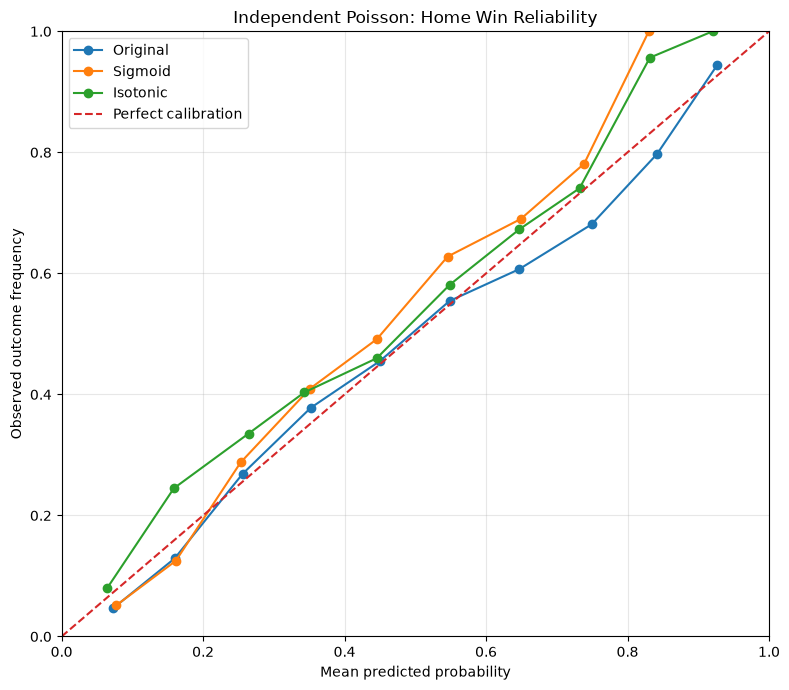

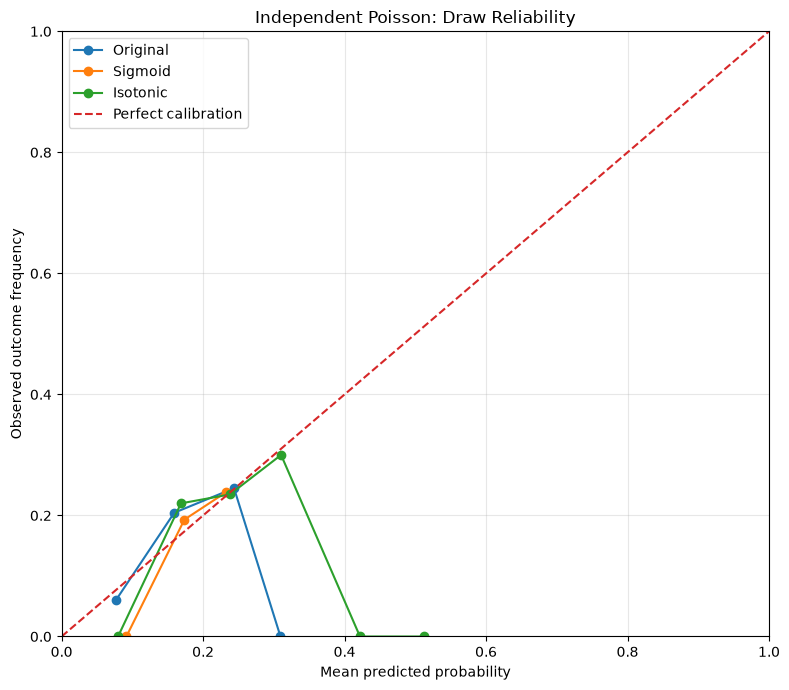

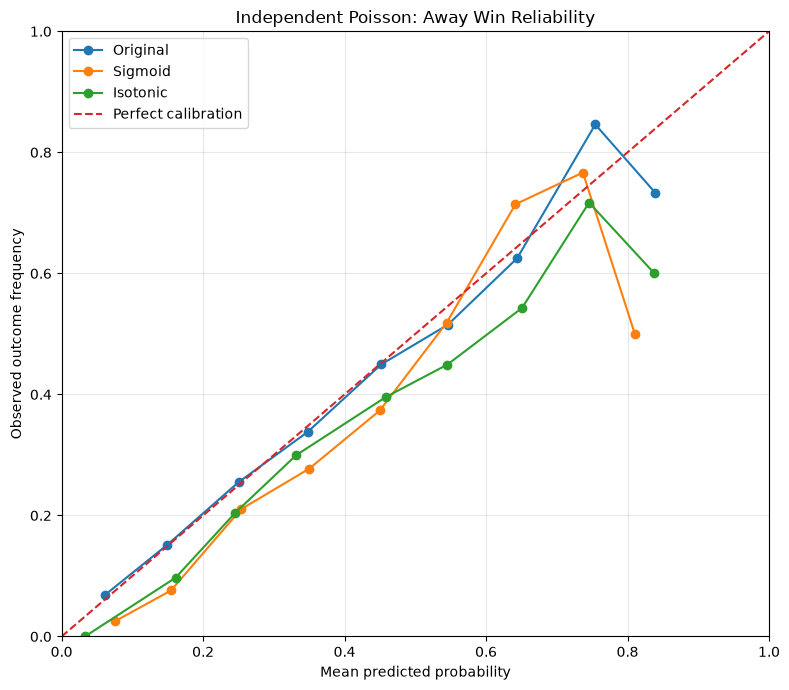

In [7]:
# ============================================================
# 8. Compare Original and Calibrated Reliability
# ============================================================


# ------------------------------------------------------------
# Convert calibrated forecasts into long outcome format
# ------------------------------------------------------------

calibrated_long_frames = []


for (
    model_name,
    calibration_method,
), method_forecasts in calibrated_predictions.groupby(
    [
        "Model",
        "CalibrationMethod",
    ],
    sort=False,
):

    for outcome in CLASS_ORDER:

        calibrated_long_frames.append(
            pd.DataFrame(
                {
                    "Model": model_name,
                    "CalibrationMethod": (
                        calibration_method
                    ),
                    "EvaluationSeason": (
                        method_forecasts[
                            "EvaluationSeason"
                        ].to_numpy()
                    ),
                    "Outcome": outcome,
                    "PredictedProbability": (
                        method_forecasts[
                            f"Probability_{outcome}"
                        ].to_numpy(
                            dtype=float
                        )
                    ),
                    "ObservedIndicator": (
                        method_forecasts[
                            "ActualOutcome"
                        ]
                        .eq(outcome)
                        .astype(int)
                        .to_numpy()
                    ),
                }
            )
        )


calibrated_long_data = pd.concat(
    calibrated_long_frames,
    ignore_index=True,
)


expected_long_rows = (
    len(
        calibrated_predictions
    )
    *
    len(
        CLASS_ORDER
    )
)


assert len(
    calibrated_long_data
) == expected_long_rows, (
    "The calibrated long-format table has an "
    "unexpected number of rows."
)


# ------------------------------------------------------------
# Assign equal-width calibration bins
# ------------------------------------------------------------

calibrated_long_data[
    "CalibrationBin"
] = pd.cut(
    calibrated_long_data[
        "PredictedProbability"
    ],
    bins=CALIBRATION_BIN_EDGES,
    labels=False,
    include_lowest=True,
    right=True,
)


assert calibrated_long_data[
    "CalibrationBin"
].notna().all(), (
    "At least one calibrated probability could not "
    "be assigned to a bin."
)


# ------------------------------------------------------------
# Calculate bin-level reliability statistics
# ------------------------------------------------------------

calibrated_reliability_bins = (
    calibrated_long_data
    .groupby(
        [
            "Model",
            "CalibrationMethod",
            "Outcome",
            "CalibrationBin",
        ],
        as_index=False,
        observed=True,
    )
    .agg(
        Forecasts=(
            "ObservedIndicator",
            "size",
        ),
        MeanPredictedProbability=(
            "PredictedProbability",
            "mean",
        ),
        ObservedFrequency=(
            "ObservedIndicator",
            "mean",
        ),
    )
)


calibrated_reliability_bins[
    "CalibrationGap"
] = (
    calibrated_reliability_bins[
        "ObservedFrequency"
    ]
    -
    calibrated_reliability_bins[
        "MeanPredictedProbability"
    ]
)


calibrated_reliability_bins[
    "AbsoluteCalibrationGap"
] = (
    calibrated_reliability_bins[
        "CalibrationGap"
    ].abs()
)


calibrated_reliability_bins[
    "BinLowerBound"
] = (
    calibrated_reliability_bins[
        "CalibrationBin"
    ]
    /
    NUMBER_OF_CALIBRATION_BINS
)


calibrated_reliability_bins[
    "BinUpperBound"
] = (
    (
        calibrated_reliability_bins[
            "CalibrationBin"
        ]
        + 1
    )
    /
    NUMBER_OF_CALIBRATION_BINS
)


# ------------------------------------------------------------
# Calculate outcome-specific ECE and MCE
# ------------------------------------------------------------

calibrated_outcome_summary_records = []


for (
    model_name,
    calibration_method,
    outcome,
), outcome_bins in calibrated_reliability_bins.groupby(
    [
        "Model",
        "CalibrationMethod",
        "Outcome",
    ],
    sort=False,
):

    total_forecasts = int(
        outcome_bins[
            "Forecasts"
        ].sum()
    )

    bin_weights = (
        outcome_bins[
            "Forecasts"
        ]
        /
        total_forecasts
    )

    expected_calibration_error = float(
        np.sum(
            bin_weights
            *
            outcome_bins[
                "AbsoluteCalibrationGap"
            ]
        )
    )

    maximum_calibration_error = float(
        outcome_bins[
            "AbsoluteCalibrationGap"
        ].max()
    )

    signed_calibration_error = float(
        np.sum(
            bin_weights
            *
            outcome_bins[
                "CalibrationGap"
            ]
        )
    )

    calibrated_outcome_summary_records.append(
        {
            "Model": model_name,
            "CalibrationMethod": (
                calibration_method
            ),
            "Outcome": outcome,
            "Forecasts": total_forecasts,
            "ExpectedCalibrationError": (
                expected_calibration_error
            ),
            "MaximumCalibrationError": (
                maximum_calibration_error
            ),
            "SignedCalibrationError": (
                signed_calibration_error
            ),
        }
    )


calibrated_outcome_summary = pd.DataFrame(
    calibrated_outcome_summary_records
)


# ------------------------------------------------------------
# Create model-method macro calibration summaries
# ------------------------------------------------------------

calibrated_macro_summary = (
    calibrated_outcome_summary
    .groupby(
        [
            "Model",
            "CalibrationMethod",
        ],
        as_index=False,
    )
    .agg(
        MacroExpectedCalibrationError=(
            "ExpectedCalibrationError",
            "mean",
        ),
        MacroMaximumCalibrationError=(
            "MaximumCalibrationError",
            "mean",
        ),
        WorstOutcomeExpectedCalibrationError=(
            "ExpectedCalibrationError",
            "max",
        ),
        MeanSignedCalibrationError=(
            "SignedCalibrationError",
            "mean",
        ),
    )
)


# ------------------------------------------------------------
# Add predictive metrics from the earlier comparison
# ------------------------------------------------------------

calibration_quality_comparison = (
    calibrated_macro_summary
    .merge(
        aggregate_calibration_comparison[
            [
                "Model",
                "CalibrationMethod",
                "LogLoss",
                "BrierScore",
                "Accuracy",
                "MeanMaximumProbability",
                "LogLossChange",
            ]
        ],
        on=[
            "Model",
            "CalibrationMethod",
        ],
        how="left",
        validate="one_to_one",
    )
    .sort_values(
        by=[
            "Model",
            "MacroExpectedCalibrationError",
        ],
        kind="mergesort",
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Identify the lowest-ECE method for each model
# ------------------------------------------------------------

best_calibration_method_by_model = (
    calibration_quality_comparison
    .sort_values(
        by=[
            "Model",
            "MacroExpectedCalibrationError",
        ],
        kind="mergesort",
    )
    .groupby(
        "Model",
        as_index=False,
        sort=False,
    )
    .first()
    [
        [
            "Model",
            "CalibrationMethod",
            "MacroExpectedCalibrationError",
            "WorstOutcomeExpectedCalibrationError",
            "LogLoss",
            "LogLossChange",
            "BrierScore",
        ]
    ]
    .rename(
        columns={
            "CalibrationMethod": (
                "LowestECEMethod"
            ),
        }
    )
)


# ------------------------------------------------------------
# Validate the results
# ------------------------------------------------------------

assert len(
    calibrated_outcome_summary
) == (
    len(
        CALIBRATION_MODELS
    )
    *
    len(
        CALIBRATION_METHODS
    )
    *
    len(
        CLASS_ORDER
    )
), (
    "Unexpected number of outcome-specific "
    "calibration rows."
)


assert len(
    calibration_quality_comparison
) == 9, (
    "Expected nine model-method calibration summaries."
)


assert (
    calibrated_outcome_summary[
        "Forecasts"
    ]
    ==
    1520
).all(), (
    "Every outcome-specific summary should contain "
    "1,520 forecasts."
)


# ------------------------------------------------------------
# Display the numerical comparison
# ------------------------------------------------------------

print(
    "Original and calibrated reliability comparison "
    "completed successfully."
)


display(
    calibration_quality_comparison[
        [
            "Model",
            "CalibrationMethod",
            "MacroExpectedCalibrationError",
            "WorstOutcomeExpectedCalibrationError",
            "MacroMaximumCalibrationError",
            "MeanSignedCalibrationError",
            "LogLoss",
            "LogLossChange",
            "BrierScore",
            "Accuracy",
            "MeanMaximumProbability",
        ]
    ].round(6)
)


print(
    "Lowest-ECE method for each model:"
)


display(
    best_calibration_method_by_model.round(6)
)


print(
    "Outcome-specific calibration errors:"
)


display(
    calibrated_outcome_summary
    .sort_values(
        by=[
            "Model",
            "CalibrationMethod",
            "Outcome",
        ],
        kind="mergesort",
    )
    .reset_index(drop=True)
    .round(6)
)


# ------------------------------------------------------------
# Reliability diagrams for Independent Poisson
# ------------------------------------------------------------

POISSON_MODEL_NAME = (
    "Independent Poisson"
)


poisson_reliability_bins = (
    calibrated_reliability_bins.loc[
        calibrated_reliability_bins[
            "Model"
        ].eq(
            POISSON_MODEL_NAME
        )
    ]
    .copy()
)


outcome_names = {
    "H": "Home Win",
    "D": "Draw",
    "A": "Away Win",
}


for outcome in CLASS_ORDER:

    figure, axis = plt.subplots(
        figsize=(8, 7)
    )

    outcome_data = (
        poisson_reliability_bins.loc[
            poisson_reliability_bins[
                "Outcome"
            ].eq(
                outcome
            )
        ]
    )

    for calibration_method in CALIBRATION_METHODS:

        method_bins = (
            outcome_data.loc[
                outcome_data[
                    "CalibrationMethod"
                ].eq(
                    calibration_method
                )
            ]
            .sort_values(
                by="MeanPredictedProbability",
                kind="mergesort",
            )
        )

        axis.plot(
            method_bins[
                "MeanPredictedProbability"
            ],
            method_bins[
                "ObservedFrequency"
            ],
            marker="o",
            label=calibration_method,
        )

    axis.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Perfect calibration",
    )

    axis.set_xlim(
        0,
        1,
    )

    axis.set_ylim(
        0,
        1,
    )

    axis.set_xlabel(
        "Mean predicted probability"
    )

    axis.set_ylabel(
        "Observed outcome frequency"
    )

    axis.set_title(
        "Independent Poisson: "
        f"{outcome_names[outcome]} Reliability"
    )

    axis.grid(
        alpha=0.3
    )

    axis.legend()

    plt.tight_layout()
    plt.show()

### Results and Interpretation

The reliability diagrams reinforce the aggregate performance results.

For home-win probabilities, all three probability versions remain reasonably close to the perfect-calibration diagonal across the central probability range. However, sigmoid and isotonic calibration tend to make larger adjustments in the higher-probability bins without producing a consistent improvement in observed reliability.

The original Independent Poisson probabilities remain competitive throughout the populated home-win range and avoid some of the more pronounced deviations introduced by the calibrated alternatives.

Draw probabilities occupy a much narrower range. Most forecasts lie below approximately 30%, while bins containing higher predicted draw probabilities contain relatively few fixtures. The sharp movements in the right-hand side of the draw reliability diagram should therefore be interpreted as sparse-bin instability rather than evidence of a stable calibration pattern.

For away wins, the original probabilities follow the calibration diagonal closely across the main probability range. Sigmoid and isotonic calibration introduce larger deviations among some of the higher-confidence forecasts.

The calibration methods occasionally improve an individual bin, but they do not provide a consistent improvement across outcomes or probability ranges.

Together with the worse out-of-sample log loss and Brier scores, the reliability diagrams show that the additional calibration layer introduces estimation noise and overcorrection.

The original Independent Poisson probabilities should therefore remain the final probability specification. Neither sigmoid nor isotonic calibration provides sufficient out-of-sample evidence to justify replacing them.

## 9. Final Probability-Model Selection

The final probability specification must be selected using genuinely unseen forecasts rather than calibration-training fit.

The decision considers:

- aggregate log loss across the 1,520 common evaluation fixtures;
- multiclass Brier score;
- reliability diagrams;
- consistency across evaluation seasons;
- the complexity introduced by an additional calibration layer.

Calibration should only replace the original probabilities when it produces a clear and repeatable out-of-sample improvement.

The preferred specification is the model-method combination with the lowest aggregate log loss. Brier score, calibration error and seasonal consistency provide supporting evidence.

In [8]:
# ============================================================
# 9. Final Probability-Model Selection
# ============================================================


# ------------------------------------------------------------
# Extract the selected probability version
# ------------------------------------------------------------

selected_probability_version = (
    aggregate_calibration_comparison
    .sort_values(
        by=[
            "LogLoss",
            "BrierScore",
        ],
        ascending=[
            True,
            True,
        ],
        kind="mergesort",
    )
    .iloc[0]
)


selected_model_name = str(
    selected_probability_version[
        "Model"
    ]
)

selected_calibration_method = str(
    selected_probability_version[
        "CalibrationMethod"
    ]
)


# ------------------------------------------------------------
# Extract the best calibrated alternative
# ------------------------------------------------------------

best_calibrated_alternative = (
    aggregate_calibration_comparison.loc[
        aggregate_calibration_comparison[
            "CalibrationMethod"
        ].ne(
            "Original"
        )
    ]
    .sort_values(
        by=[
            "LogLoss",
            "BrierScore",
        ],
        ascending=[
            True,
            True,
        ],
        kind="mergesort",
    )
    .iloc[0]
)


# ------------------------------------------------------------
# Retrieve the complete five-season baseline result
# ------------------------------------------------------------

selected_five_season_baseline = (
    baseline_model_metrics.loc[
        baseline_model_metrics[
            "Model"
        ].eq(
            selected_model_name
        )
    ]
    .iloc[0]
)


selected_baseline_calibration = (
    model_calibration_summary.loc[
        model_calibration_summary[
            "Model"
        ].eq(
            selected_model_name
        )
    ]
    .iloc[0]
)


# ------------------------------------------------------------
# Construct the final selection table
# ------------------------------------------------------------

final_model_selection = pd.DataFrame(
    [
        {
            "SelectedModel": (
                selected_model_name
            ),
            "SelectedProbabilityMethod": (
                selected_calibration_method
            ),
            "CommonPeriodFixtures": int(
                selected_probability_version[
                    "Fixtures"
                ]
            ),
            "CommonPeriodLogLoss": float(
                selected_probability_version[
                    "LogLoss"
                ]
            ),
            "CommonPeriodBrierScore": float(
                selected_probability_version[
                    "BrierScore"
                ]
            ),
            "CommonPeriodAccuracy": float(
                selected_probability_version[
                    "Accuracy"
                ]
            ),
            "FiveSeasonWalkForwardLogLoss": float(
                selected_five_season_baseline[
                    "LogLoss"
                ]
            ),
            "FiveSeasonWalkForwardBrierScore": float(
                selected_five_season_baseline[
                    "BrierScore"
                ]
            ),
            "BaselineMacroECE": float(
                selected_baseline_calibration[
                    "MacroExpectedCalibrationError"
                ]
            ),
            "BestCalibratedAlternativeModel": str(
                best_calibrated_alternative[
                    "Model"
                ]
            ),
            "BestCalibratedAlternativeMethod": str(
                best_calibrated_alternative[
                    "CalibrationMethod"
                ]
            ),
            "BestCalibratedAlternativeLogLoss": float(
                best_calibrated_alternative[
                    "LogLoss"
                ]
            ),
            "CalibratedAlternativeMinusSelected": float(
                best_calibrated_alternative[
                    "LogLoss"
                ]
                -
                selected_probability_version[
                    "LogLoss"
                ]
            ),
            "Decision": (
                "Retain original probabilities"
                if selected_calibration_method
                == "Original"
                else
                "Apply probability calibration"
            ),
        }
    ]
)


# ------------------------------------------------------------
# Validate the expected final decision
# ------------------------------------------------------------

assert selected_model_name == (
    "Independent Poisson"
), (
    "The selected final model differs from the "
    "expected Independent Poisson result."
)


assert selected_calibration_method == (
    "Original"
), (
    "A calibrated probability method unexpectedly "
    "outperformed the original probabilities."
)


assert (
    final_model_selection.loc[
        0,
        "CalibratedAlternativeMinusSelected",
    ]
    >
    0
), (
    "The best calibrated alternative should have "
    "higher log loss than the selected specification."
)


# ------------------------------------------------------------
# Display the final decision
# ------------------------------------------------------------

print(
    "Final probability-model selection completed."
)

print(
    "Selected model:",
    selected_model_name,
)

print(
    "Selected probability method:",
    selected_calibration_method,
)

print(
    "Common-period log loss:",
    round(
        float(
            selected_probability_version[
                "LogLoss"
            ]
        ),
        6,
    ),
)

print(
    "Five-season walk-forward log loss:",
    round(
        float(
            selected_five_season_baseline[
                "LogLoss"
            ]
        ),
        6,
    ),
)

display(
    final_model_selection.round(6)
)

display(
    aggregate_calibration_comparison[
        [
            "OverallRank",
            "Model",
            "CalibrationMethod",
            "Fixtures",
            "LogLoss",
            "BrierScore",
            "Accuracy",
            "LogLossChange",
            "LogLossImprovementPercent",
        ]
    ].round(6)
)

Final probability-model selection completed.
Selected model: Independent Poisson
Selected probability method: Original
Common-period log loss: 0.964879
Five-season walk-forward log loss: 0.985002


,SelectedModel,SelectedProbabilityMethod,CommonPeriodFixtures,CommonPeriodLogLoss,CommonPeriodBrierScore,CommonPeriodAccuracy,FiveSeasonWalkForwardLogLoss,FiveSeasonWalkForwardBrierScore,BaselineMacroECE,BestCalibratedAlternativeModel,BestCalibratedAlternativeMethod,BestCalibratedAlternativeLogLoss,CalibratedAlternativeMinusSelected,Decision
0,Independent Poisson,Original,1520,0.964879,0.5739,0.546053,0.985002,0.585181,0.021113,Independent Poisson,Sigmoid,0.979152,0.014273,Retain original probabilities


,OverallRank,Model,CalibrationMethod,Fixtures,LogLoss,BrierScore,Accuracy,LogLossChange,LogLossImprovementPercent
0,1,Independent Poisson,Original,1520,0.964879,0.573900,0.546053,0.000000,0.000000
1,2,Direct Probability Ensemble,Original,1520,0.968902,0.575592,0.548026,0.000000,0.000000
2,3,Tuned Random Forest,Original,1520,0.971097,0.576400,0.548026,0.000000,0.000000
3,4,Independent Poisson,Sigmoid,1520,0.979152,0.582928,0.526974,0.014273,-1.479202
4,5,Direct Probability Ensemble,Sigmoid,1520,0.981674,0.584110,0.536842,0.012773,-1.318280
5,6,Tuned Random Forest,Sigmoid,1520,0.983888,0.585053,0.535526,0.012791,-1.317135
6,7,Independent Poisson,Isotonic,1520,0.988119,0.588018,0.526974,0.023239,-2.408512
7,8,Direct Probability Ensemble,Isotonic,1520,1.022542,0.588507,0.540789,0.053640,-5.536202
8,9,Tuned Random Forest,Isotonic,1520,1.048426,0.586228,0.536184,0.077328,-7.963000


## 10. Export Calibration Results

The calibration experiment generated original, sigmoid-calibrated and isotonic-calibrated probabilities for 1,520 unseen fixtures per model.

The outputs will be exported for later analysis and repository reproducibility.

The exports include:

- fixture-level calibrated probability distributions;
- fold-level calibration metrics;
- aggregate model-method rankings;
- fitted calibrator diagnostics;
- original five-season model metrics;
- original outcome-specific calibration summaries;
- the final probability-model selection.

The upcoming bookmaker-comparison notebook will use the selected original Independent Poisson probabilities rather than the unsuccessful calibrated alternatives.

In [9]:
# ============================================================
# 10. Export Calibration Results
# ============================================================


# ------------------------------------------------------------
# Create the output directory
# ------------------------------------------------------------

calibration_output_directory = (
    project_root
    / "outputs"
    / "calibration"
)

calibration_output_directory.mkdir(
    parents=True,
    exist_ok=True,
)


# ------------------------------------------------------------
# Prepare export copies
# ------------------------------------------------------------

calibrated_predictions_export = (
    calibrated_predictions.copy()
)

calibration_fold_metrics_export = (
    calibration_fold_metrics.copy()
)

aggregate_calibration_export = (
    aggregate_calibration_comparison.copy()
)

calibrator_diagnostics_export = (
    calibrator_diagnostics.copy()
)

baseline_model_metrics_export = (
    baseline_model_metrics.copy()
)

outcome_calibration_summary_export = (
    outcome_calibration_summary.copy()
)

final_model_selection_export = (
    final_model_selection.copy()
)


# ------------------------------------------------------------
# Standardise exported dates
# ------------------------------------------------------------

if date_column in calibrated_predictions_export.columns:

    calibrated_predictions_export[
        date_column
    ] = pd.to_datetime(
        calibrated_predictions_export[
            date_column
        ],
        errors="raise",
    ).dt.strftime(
        "%Y-%m-%d"
    )


# ------------------------------------------------------------
# Define export paths
# ------------------------------------------------------------

calibrated_probability_path = (
    calibration_output_directory
    / "calibrated_fixture_probabilities.csv"
)

calibration_fold_metric_path = (
    calibration_output_directory
    / "calibration_fold_metrics.csv"
)

aggregate_calibration_path = (
    calibration_output_directory
    / "calibration_model_method_ranking.csv"
)

calibrator_diagnostic_path = (
    calibration_output_directory
    / "calibrator_diagnostics.csv"
)

baseline_metric_path = (
    calibration_output_directory
    / "baseline_model_metrics.csv"
)

outcome_calibration_path = (
    calibration_output_directory
    / "baseline_outcome_calibration_summary.csv"
)

final_selection_path = (
    calibration_output_directory
    / "final_probability_model_selection.csv"
)


# ------------------------------------------------------------
# Export the results
# ------------------------------------------------------------

calibrated_predictions_export.to_csv(
    calibrated_probability_path,
    index=False,
)

calibration_fold_metrics_export.to_csv(
    calibration_fold_metric_path,
    index=False,
)

aggregate_calibration_export.to_csv(
    aggregate_calibration_path,
    index=False,
)

calibrator_diagnostics_export.to_csv(
    calibrator_diagnostic_path,
    index=False,
)

baseline_model_metrics_export.to_csv(
    baseline_metric_path,
    index=False,
)

outcome_calibration_summary_export.to_csv(
    outcome_calibration_path,
    index=False,
)

final_model_selection_export.to_csv(
    final_selection_path,
    index=False,
)


# ------------------------------------------------------------
# Validate the exports
# ------------------------------------------------------------

calibration_export_paths = [
    calibrated_probability_path,
    calibration_fold_metric_path,
    aggregate_calibration_path,
    calibrator_diagnostic_path,
    baseline_metric_path,
    outcome_calibration_path,
    final_selection_path,
]


for export_path in calibration_export_paths:

    assert export_path.exists(), (
        f"Expected calibration export was not created: "
        f"{export_path}"
    )


assert len(
    calibrated_predictions_export
) == 13680, (
    "Expected 13,680 fixture-level probability rows."
)


assert len(
    calibration_fold_metrics_export
) == 36, (
    "Expected 36 fold-level metric rows."
)


assert len(
    aggregate_calibration_export
) == 9, (
    "Expected nine model-method ranking rows."
)


assert len(
    final_model_selection_export
) == 1, (
    "Expected one final model-selection row."
)


# ------------------------------------------------------------
# Display export summary
# ------------------------------------------------------------

calibration_export_summary = pd.DataFrame(
    [
        {
            "Output": (
                "Calibrated fixture probabilities"
            ),
            "Rows": len(
                calibrated_predictions_export
            ),
            "File": (
                calibrated_probability_path.name
            ),
        },
        {
            "Output": (
                "Calibration fold metrics"
            ),
            "Rows": len(
                calibration_fold_metrics_export
            ),
            "File": (
                calibration_fold_metric_path.name
            ),
        },
        {
            "Output": (
                "Model-method ranking"
            ),
            "Rows": len(
                aggregate_calibration_export
            ),
            "File": (
                aggregate_calibration_path.name
            ),
        },
        {
            "Output": (
                "Calibrator diagnostics"
            ),
            "Rows": len(
                calibrator_diagnostics_export
            ),
            "File": (
                calibrator_diagnostic_path.name
            ),
        },
        {
            "Output": (
                "Baseline model metrics"
            ),
            "Rows": len(
                baseline_model_metrics_export
            ),
            "File": (
                baseline_metric_path.name
            ),
        },
        {
            "Output": (
                "Outcome calibration summary"
            ),
            "Rows": len(
                outcome_calibration_summary_export
            ),
            "File": (
                outcome_calibration_path.name
            ),
        },
        {
            "Output": (
                "Final model selection"
            ),
            "Rows": len(
                final_model_selection_export
            ),
            "File": (
                final_selection_path.name
            ),
        },
    ]
)


print(
    "Calibration outputs exported successfully."
)

print(
    "Output directory:",
    calibration_output_directory.relative_to(
        project_root
    ),
)

display(
    calibration_export_summary
)

Calibration outputs exported successfully.
Output directory: outputs\calibration


,Output,Rows,File
0,Calibrated fixture probabilities,13680,calibrated_fixture_probabilities.csv
1,Calibration fold metrics,36,calibration_fold_metrics.csv
2,Model-method ranking,9,calibration_model_method_ranking.csv
3,Calibrator diagnostics,72,calibrator_diagnostics.csv
4,Baseline model metrics,5,baseline_model_metrics.csv
5,Outcome calibration summary,15,baseline_outcome_calibration_summary.csv
6,Final model selection,1,final_probability_model_selection.csv


## 11. Conclusions, Limitations and Next Stage

### Final Calibration Conclusion

This notebook evaluated the calibration quality of the project’s walk-forward probability forecasts and tested whether an additional calibration layer improved later unseen-season performance.

Independent Poisson was already the best-calibrated original model, achieving a five-season macro Expected Calibration Error of:

$$
\operatorname{ECE}_{\text{Poisson}}
=
0.021113.
$$

It also retained the lowest five-season walk-forward log loss:

$$
\operatorname{LogLoss}_{\text{Poisson}}
=
0.985002.
$$

### Chronological Calibration Results

Sigmoid and isotonic calibration were fitted using earlier out-of-sample forecasts and evaluated on later unseen seasons.

Across the common four-season evaluation period, the leading results were:

| Rank | Model | Probability method | Log loss |
|---:|---|---|---:|
| 1 | Independent Poisson | Original | 0.964879 |
| 2 | Direct Probability Ensemble | Original | 0.968902 |
| 3 | Tuned Random Forest | Original | 0.971097 |
| 4 | Independent Poisson | Sigmoid | 0.979152 |

Neither calibration method improved aggregate performance.

For Independent Poisson, sigmoid calibration increased log loss by:

$$
0.979152-0.964879
=
0.014273.
$$

This represents a deterioration of approximately 1.48%.

Isotonic calibration performed still worse in aggregate. Its flexible non-parametric mapping appears to have overfit the relatively small calibration-training samples.

### Reliability Interpretation

The original Independent Poisson probabilities remained close to the perfect-calibration diagonal throughout the main populated probability ranges.

The largest deviations occurred in rare high-confidence bins, where small sample sizes produced unstable observed frequencies.

Sigmoid and isotonic calibration occasionally improved individual bins or individual seasons, but these local improvements were not consistent across outcomes or time.

The calibrated methods frequently overcorrected probabilities and produced worse log loss and Brier scores.

### Final Model Decision

The final probability specification remains:

> **Independent Poisson with its original, uncalibrated probability distribution.**

No additional sigmoid or isotonic transformation will be applied.

This decision is supported by:

- the lowest five-season walk-forward log loss;
- the lowest original macro calibration error;
- three seasonal walk-forward wins;
- the lowest common-period calibration-evaluation log loss;
- better Brier score than the calibrated alternatives;
- no consistent reliability improvement from recalibration.

### Strengths

The calibration design:

- used genuinely out-of-sample walk-forward predictions;
- preserved chronological order;
- trained calibrators only on earlier seasons;
- evaluated all methods on identical unseen fixtures;
- compared both predictive and calibration metrics;
- avoided selecting a calibration method from in-sample fit.

### Limitations

The first calibration fold used only 380 forecasts, which is a limited sample for estimating three outcome-specific calibration functions.

Isotonic regression is particularly vulnerable to overfitting with small samples.

The one-vs-rest calibration approach estimates each outcome independently before renormalisation. This is practical but does not model the full multiclass probability simplex jointly.

Equal-width calibration bins contain very different numbers of fixtures. Extreme-probability bins are sparse and produce unstable Maximum Calibration Error estimates.

Calibration relationships may also change as league scoring conditions and home advantage evolve.

### Next Stage

The final original Independent Poisson probabilities will be compared against bookmaker-implied probabilities in:

`08_bookmaker_comparison.ipynb`

The next notebook will:

- load historical pre-match bookmaker odds;
- convert odds into implied probabilities;
- remove the bookmaker margin;
- compare model and market log loss;
- measure model-market disagreement;
- identify candidate value bets;
- backtest fixed-stake and potentially fractional-Kelly strategies;
- calculate return on investment and maximum drawdown.

The objective will not merely be to predict match outcomes.

It will test whether the model contains information not already reflected in betting-market prices.